# Семинар 4. Итерационные методы решения СЛАУ (продолжение)

*Версия от 01.09.2026*

*Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 4](https://www.youtube.com/live/1MzfHvgqb78?si=bpiHgBxvgt-9TJEO&t=605) (начало темы),  [лекция 5](https://www.youtube.com/live/9yDoZU_WkuQ?si=FucSoS4marfSNVIz&t=73) (продолжение). Желательно также предварительно изучить материалы третьего семинара.*

Предполагается, что читатель знает

* принцип построения метода простых итераций (МПИ),
* критерий сходимости МПИ,
* определение спектрального радиуса матрицы $\rho$ и оценку сверху на $\rho$,
* определение невязки $\textbf{r}^{(s)}$.

# Введение

На прошлом семинаре мы приступили к изучению итерационных методов решения СЛАУ. Напомним, что основная особенность методов этого класса заключается в возможности управлять количеством выполняемых итераций путём изменения требований к точности искомого приближённого решения. В связи с этой особенностью итерационные методы часто оказываются более эффективными, чем прямые методы, и позволяют найти решение СЛАУ большой размерности за разумное время.

Знакомство с итерационными методами мы начали с подробного изучения метода простых итераций (МПИ). Для его построения мы переписали СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ в эквивалентном виде

$$\textbf{x}=(\textbf{E}-\tau\textbf{A})\textbf{x}+\tau\textbf{f}\equiv \textbf{R}\textbf{x}+\textbf{F}.$$

Затем мы расставили индексы итераций и получили формулу для вычисления последовательных приближений к точному решению $\textbf{x}=\textbf{u}$:

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}.$$

Мы видели, что сходимость метода целиком определяется свойствами оператора перехода $\textbf{R}$, которые в данном случае зависят от значения итерационного параметра $\tau$. Напомним, что МПИ сходится тогда и только тогда, когда модули всех собственных значений матрицы $\textbf{R}$ оказываются строго меньше единицы. Это требование ограничивает возможные значения параметра $\tau$. Вид спектра оператора перехода определяет и оптимальное значение параметра $\tau_\text{opt}$, при котором сходимость оказывается наиболее быстрой.

В настоящем семинаре мы продолжим изучение итерационных методов решения СЛАУ и рассмотрим ещё три "классических" метода: Якоби, Зейделя и последовательной верхней релаксации (ПВР). Из них первые два являются медленными и редко используются на практике. Третий метод — метод ПВР — имеет среднюю скорость сходимости, и поэтому может применяться для решения реальных задач.

Мы обсудим также принцип релаксации построения итерационных процессов и коснёмся методов вариационного типа. В заключительной части семинара будут рассмотрены два итерационных метода решения СЛАУ с разреженной матрицей, применяемые в современной вычислительной практике.

Предварительно изложим некоторые общие сведения о способах построения и записи итерационных процессов.

# Двухслойные итерационные процессы

Многие итерационные методы решения СЛАУ удаётся построить по аналогии с МПИ. Именно, рассматриваемая СЛАУ каким-либо способом приводится к эквивалентному виду

$$\textbf{x}=\textbf{R}\textbf{x}+\textbf{F}.$$

Затем расставляются индексы итераций и получается итерационный процесс, который внешне тождественен МПИ:

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}.$$

При таком подходе различные методы отличаются лишь способами перехода к эквивалентной СЛАУ, т.е. конкретными выражениями для матрицы $\textbf{R}$ и вектора $\textbf{F}$.

Итерационные процессы, задаваемые последней формулой, принято называть **двухслойными**, поскольку в них каждое следующее приближение $\textbf{x}^{(s+1)}$ зависит только от предыдущего приближения $\textbf{x}^{(s)}$ и не зависит от приближений $\textbf{x}^{(s-1)}$, $\textbf{x}^{(s-2)}$ и т.д. (т.е. в расчёте задействованы лишь два соседних "слоя"). Можно рассматривать и **многослойные** методы решения СЛАУ. Мы не будем на них останавливаться.

Центральным результатом всей теории итерационных методов является следующая теорема, дающая необходимое и достаточное условие сходимости (двухслойного) итерационного процесса.

**Теорема 1 (общий критерий сходимости итерационных методов).** Двухслойный итерационный процесс вида

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}$$

сходится при любом начальном приближении $\textbf{x}^{(0)}$ в том и только в том случае, если спектральный радиус оператора перехода *строго* меньше единицы:

$$\rho(\textbf{R})<1.$$

Иначе говоря, модули **всех** собственных значений матрицы $\textbf{R}$ должны быть строго меньше единицы (т.е. все собственные значения должны лежать в единичном круге на комплексной плоскости). Это требование мы уже встречали при обсуждении сходимости МПИ.

Двухслойные итерационные процессы часто записывают несколько иначе:

$$\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}.$$

На первый взгляд эта запись эквивалентна записи в терминах оператора перехода $\textbf{R}$ (если матрица $\textbf{M}$ обратима) и не вносит ничего нового. Действительно, достаточно положить $\textbf{R}=\textbf{M}^{-1}\textbf{N}$ и $\textbf{F}=\textbf{M}^{-1}\textbf{f}$, чтобы перейти от одного вида метода к другому. Однако при более внимательном рассмотрении различие формул

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}\quad\text{и}\quad\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}$$

оказывается существенным. Запись в терминах матриц $\textbf{M}$ и $\textbf{N}$ более конструктивна и в некоторых источниках принимается за основную.

В самом деле, из этой записи следует, что для построения итерационного метода решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ достаточно представить матрицу $\textbf{A}$ в виде разности $\textbf{M}-\textbf{N}$ так, чтобы матрица $\textbf{M}$ была невырожденной. Такое представление называется **расщеплением** матрицы $\textbf{A}$; матрица $\textbf{M}$ называется **матрицей расщепления**. Конечно, не любое расщепление матрицы СЛАУ может быть положено в основу итерационного процесса. Поскольку $\textbf{R}=\textbf{M}^{-1}\textbf{N}$, сходимость метода будет иметь место лишь при условии $\rho\big(\textbf{M}^{-1}\textbf{N}\big)<1$ (в силу теоремы 1), т.е. матрица расщепления должна выбираться по крайней мере с учётом этого условия. Однако это требование оказывается не единственным.

Из формулы

$$\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}$$

легко понять, как находится новое приближение $\textbf{x}^{(s+1)}$. Если $\textbf{M}=\textbf{E}$, то вектор $\textbf{x}^{(s+1)}$ уже выражен явно, а если $\textbf{M}\neq\textbf{E}$ (и матрица $\textbf{M}$ невырожденна), то вектор $\textbf{x}^{(s+1)}$ задан неявно и **на каждом шаге процесса возникает подзадача — приходится решать СЛАУ с матрицей** $\textbf{M}$. Если выбрать матрицу расщепления $\textbf{M}$ неудачно (например, взять её плотной), то сложность подзадачи окажется сравнимой со сложностью исходной задачи и предложенный итерационный процесс утратит смысл.

Из сказанного следует, что интерес представляют лишь такие итерационные методы, в которых матрица $\textbf{M}$ имеет какую-то специальную структуру, благодаря которой решение СЛАУ с такой матрицей (прямым методом) оказывается менее трудоёмким, чем решение СЛАУ с матрицей $\textbf{A}$. В простейших случаях матрица $\textbf{M}$ берётся диагональной или треугольной (мы увидим это ниже, когда будем строить методы Якоби и Зейделя). Возможны и более сложные варианты. Например, можно построить итерационный процесс, на каждом шаге которого СЛАУ с матрицей расщепления будет решаться методом прогонки (он имеет линейную вычислительную сложность).

Следует помнить, что на практике при организации итерационных процессов, как правило, избегают вычисления обратных матриц. По этой причине формула $\textbf{R}=\textbf{M}^{-1}\textbf{N}$ не должна рассматриваться в качестве расчётной. Если оператор перехода некоторого метода записан в таком виде, то можно утверждать, что на каждом шаге процесса требуется решать СЛАУ с матрицей $\textbf{M}$. В отдельных случаях это можно сделать аналитически, и тогда удаётся получить расчётные формулы метода.

Более подробно о решениях СЛАУ методами, использующими идею расщепления, мы поговорим в весеннем семестре, когда будем обсуждать численное решение дифференциальных уравнений в частных производных эллиптического типа.

# Методы Якоби и Зейделя

Итак, при построении итерационных методов решения СЛАУ на основе идеи расщепления стараются так подбирать матрицу $\textbf{M}$, чтобы СЛАУ с этой матрицей сравнительно легко решалась некоторым прямым методом. Среди всех прямых методов ведущую роль играет, как известно, метод Гаусса. Очевидно, что он особенно просто формулируется в двух случаях: когда матрица решаемой системы диагональна и когда она является треугольной (для определённости — нижней треугольной). Выбрав соответствующие матрицы расщепления $\textbf{M}$, мы получим два итерационных метода. Первый из них называется **методом Якоби**, второй — **методом Зейделя** (иногда Гаусса—Зейделя).

Для удобства представим матрицу СЛАУ $\textbf{A}$ как **сумму** трёх матриц:

$$\textbf{A}=\textbf{L}+\textbf{D}+\textbf{U},$$

где $\textbf{D}=\text{diag}(d_i)$ — диагональная матрица, а $\textbf{L}=(l_{ij})$ и $\textbf{U}=(u_{ij})$ — соответственно нижняя треугольная и верхняя треугольная матрицы **с нулями на главой диагонали**. **Не следует путать указанное представление матрицы $\textbf{A}$ с её $\textbf{LU}$-разложением (имеющим вид $\textbf{A}=\textbf{L}\textbf{U}$)!**

Чтобы построить метод Якоби, выбираем матрицу расщепления $\textbf{M}=\textbf{D}$. Тогда $\textbf{N}=-\textbf{L}-\textbf{U}$. Итерационный процесс приобретает вид:

$$\textbf{D}\textbf{x}^{(s+1)}=-\textbf{L}\textbf{x}^{(s)}-\textbf{U}\textbf{x}^{(s)}+\textbf{f}.$$

Переходя к покомпонентной записи (для $i$-го уравнения), получаем:

$$d_ix_i^{(s+1)}=-\sum\limits_{j=1}^n l_{ij}x_j^{(s)}-\sum\limits_{j=1}^n u_{ij}x_j^{(s)}+f_i,\quad i=1,\,2,\,\dots,\, n.$$

Как видим, компоненты $(s+1)$-го приближения действительно очень легко выражаются явно — за счёт диагональной структуры матрицы расщепления (предполагается, что все $d_i$ отличны от нуля):

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^n l_{ij}x_j^{(s)}-\sum\limits_{j=1}^n u_{ij}x_j^{(s)}\bigg)\Big/d_i,\quad i=1,\,2,\,\dots,\, n.$$

Остаётся только заметить, что

$$d_i=a_{ii};\qquad l_{ij}=
  \begin{cases}
    a_{ij}, &i> j,\\
    0, &i\leq j;
  \end{cases}
  \qquad u_{ij}=
  \begin{cases}
    0, &i\geq j,\\
    a_{ij}, &i< j.
  \end{cases}$$

Поэтому

$$\sum\limits_{j=1}^n l_{ij}x_j^{(s)}=\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s)},\quad \sum\limits_{j=1}^n u_{ij}x_j^{(s)}=\sum\limits_{j=i+1}^{n} a_{ij}x_j^{(s)}.$$

Напомним, что если верхний предел суммы меньше нижнего, то сумма считается равной нулю. Окончательно:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s)}-\sum\limits_{j=i+1}^{n} a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\, n.$$

Эта формула даёт покомпонентную запись метода Якоби и является основной расчётной формулой, используемой при его программных реализациях. Подчеркнём, что **порядок вычисления компонент** на текущей итерации метода Якоби **может быть любым** ($n$ значений индекса $i$ могут идти в любой последовательности).

Похожим образом строится метод Зейделя. В этом случае за матрицу расщепления принимается нижняя треугольная матрица (в которую входят и диагональные элементы матрицы $\textbf{A}$), т.е. $\textbf{M}=\textbf{L}+\textbf{D}$, а $\textbf{N}=-\textbf{U}$. В векторно-матричной форме метод записывается так:

$$(\textbf{L}+\textbf{D})\textbf{x}^{(s+1)}=-\textbf{U}\textbf{x}^{(s)}+\textbf{f}.$$

Рассуждая так же, как и выше, можно прийти к покомпонентной записи метода Зейделя:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^{n} a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\, n.$$

Эта формула отличается от формулы метода Якоби расстановкой индексов итераций: неизвестные из первой суммы имеют индекс $s+1$, а не индекс $s$. Таким образом, явное выражение для компонент приближённого решения $x_i^{(s+1)}$ не получается так же просто, как в методе Якоби. С практической точки зрения это означает, что **в методе Зейделя порядок вычисления компонент строго фиксирован**: их нужно находить от первой к последней (значения индекса $i$ должны последовательно увеличиваться, иначе невозможно будет найти первую сумму из правой части).

Разумеется, и метод Якоби, и метод Зейделя можно было бы получить и без использования понятия матрицы расщепления. В самом деле, ведь для подготовки СЛАУ к выполнению итераций достаточно как-либо уединить вектор неизвестных $\textbf{x}$ в левой части. Простой способ сделать это подсказывается покомпонентной формой СЛАУ, в которой $i$-е уравнение выглядит так:

$$\sum\limits_{j=1}^na_{ij}x_j=f_i,\quad i=1,\,2,\,\dots,\,n.$$

Очевидно, что можно выписать отдельно $i$-е слагаемое суммы:

$$\sum\limits_{j=1}^{i-1}a_{ij}x_j+a_{ii}x_i+\sum\limits_{j=i+1}^{n}a_{ij}x_j=f_i,\quad i=1,\,2,\,\dots,\,n,$$

а затем выразить компоненту $x_i$ (в предположении, что $a_{ii}\neq 0$):

$$x_i=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j-\sum\limits_{j=i+1}^n a_{ij}x_j\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

С помощью полученного равенства уже можно строить итерационные процессы — для этого нужно расставить индексы итераций. Естественно сделать это так же, как и в МПИ: справа поставить индекс текущей итерации ($s$), слева — индекс следующей итерации ($s+1$):

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

Мы получили уже известную нам формулу метода Якоби с произвольным порядком подсчёта компонент решения.

Далее можно условиться вычислять компоненты решения в строго определённом порядке. Естественно выбрать порядок, при котором индекс $i$ последовательно пробегает значения от $1$ до $n$. Тогда при расчёте, например, компоненты $x_3^{(s+1)}$ уже будут известны компоненты $x_1^{(s+1)}$ и $x_2^{(s+1)}$, так что их можно будет вставить в первую сумму вместо компонент $x_1^{(s)}$ и $x_2^{(s)}$. Иначе говоря, благодаря фиксированному порядку значений индекса $i$ можно заменить индекс итераций $s$ в первой сумме на индекс $s+1$ и прийти к формуле метода Зейделя:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

Выше мы специально разобрали способы построения методов Якоби и Зейделя в векторно-матричном виде, чтобы показать на их примере, по какому принципу получаются все основные итерационные методы решения СЛАУ. Повторим, что ключевая идея здесь — так построить расщепление $\textbf{A}=\textbf{M}-\textbf{N}$, чтобы СЛАУ с матрицей $\textbf{M}$ решалась легче, чем СЛАУ с матрицей $\textbf{A}$.

Векторно-матричные формулы, благодаря своей компактности, удобны для теоретического анализа итерационных методов. На практике же используются покомпонентные формулы; расчёт по ним обычно осуществляют в циклах. Для ускорения циклов (и вообще для повышения эффективности программ, реализующих численные методы) часто прибегают к **параллельным вычислениям**.

Из сказанного выше следует, что параллельные расчёты можно легко организовать в случае метода Якоби, поскольку в нём разные компоненты нового приближения к решению СЛАУ не зависят друг от друга (в отличие от метода Зейделя). При большом числе параллельных потоков эффективность метода Якоби может увеличиться настолько, что он из медленного (при последовательных расчётах) метода превратится в достаточно эффективный метод, представляющий практический интерес.

Приведённый пример показывает, что **не следует категорично подразделять численные методы на старые** (ненужные, бесполезные) **и новые** (полезные). Иногда бывает так, что усовершенствование вычислительной техники или какое-либо другое продвижение в науке открывает новые перспективы для использования уже известных методов. Подобные примеры можно найти не только среди методов решения СЛАУ, но и среди разностных схем для уравнений в частных производных. Это — ещё одна причина изучать классические методы (и вообще вычислительную математику): в любой момент может возникнуть потребность пересмотреть элементарные основы предмета для того, чтобы в конце концов прийти к чему-то новому.

Написание программ для методов Якоби и Зейделя мы оставляем читателю (см. практическую задачу A).

## Каноническая форма двухслойных итерационных процессов

Иногда итерационные процессы вида

$$\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}$$

записывают по-другому. Так как $\textbf{A}=\textbf{M}-\textbf{N}$, то $\textbf{N}=\textbf{M}-\textbf{A}$, т.е.

$$\textbf{M}(\textbf{x}^{(s+1)}-\textbf{x}^{(s)})+\textbf{A}\textbf{x}^{(s)}=\textbf{f}.$$

Положим $\textbf{B}=\tau\textbf{M}$, где $\tau$ — некоторое число (итерационный параметр). Тогда

$$\textbf{B}\,\frac{\textbf{x}^{(s+1)}-\textbf{x}^{(s)}}{\tau}+\textbf{A}\textbf{x}^{(s)}=\textbf{f}.$$

Можно обобщить этот итерационный метод, снабдив параметр $\tau$ индексом $s$, т.е. допустив использование не одного параметра, а последовательности из параметров:

$$\textbf{B}\,\frac{\textbf{x}^{(s+1)}-\textbf{x}^{(s)}}{\tau_s}+\textbf{A}\textbf{x}^{(s)}=\textbf{f}.$$

Мы пришли к так называемой **канонической форме двухслойных итерационных процессов**. Нетрудно заметить, что эта формула охватывает все рассмотренные ранее итерационные методы:

* при $\textbf{B}=\textbf{E}$, $\tau_s=\tau$ для всех $s$ получаем (однопараметрический) МПИ,

* при $\textbf{B}=\textbf{E}$, $\tau_s=\tau_k$, где $k=(s\text{ mod } m)+1$, получаем $m$-шаговый МПИ (символ $\text{mod}$ означает операцию взятия остатка от деления целых чисел),

* при $\textbf{B}=\textbf{D}$, $\tau_s=1$ для всех $s$ получаем метод Якоби,

* при $\textbf{B}=\textbf{L}+\textbf{D}$, $\tau_s=1$ для всех $s$ получаем метод Зейделя.

Процессы с $\textbf{B}=\textbf{E}$ называются **явными**, а с $\textbf{B}\neq\textbf{E}$ — **неявными**. После сказанного выше смысл этих названий очевиден: во втором случае, в отличие от первого, для нахождения вектора $\textbf{x}^{(s+1)}$ на каждой итерации приходится решать СЛАУ.

Заметим, что отношение $(\textbf{x}^{(s+1)}-\textbf{x}^{(s)})/\tau_s$ из левой части канонической формы двухслойных процессов можно интерпретировать как конечно-разностную аппроксимацию производной $\dot{\textbf{x}}(t)$. Если решение, как принято говорить, "**вышло на стационар**", то $\dot{\textbf{x}}(t)=0$ и верно $\textbf{A}\textbf{x}=\textbf{f}$. Таким образом, искусственное введение в стационарную задачу производной по времени даёт не только формулу для расчёта новых приближений, но и критерий остановки итераций — малость разности $\textbf{x}^{(s+1)}-\textbf{x}^{(s)}$ (в данном случае — в смысле нормы). С подобным приёмом мы ещё столкнёмся в весеннем семестре.

Надо сказать, что в ряде книг двухслойные итерационные процессы записываются так:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\textbf{C}^{(s)}\big(\textbf{f}-\textbf{A}\textbf{x}^{(s)}\big)\equiv \textbf{x}^{(s)}+\textbf{C}^{(s)}\textbf{r}^{(s)}.$$

Здесь $\textbf{C}^{(s)}$ — некоторая последовательность невырожденных матриц. Очевидно, что внешне эта форма итерационных методов мало чем отличается от канонической (отличие сводится к переобозначению $\textbf{C}^{(s)}=\tau_s\textbf{B}^{-1}$), хотя и оказывается более общей (матрицы $\textbf{C}^{(s)}$ могут меняться как угодно, а не только за счёт умножения заданной матрицы $\textbf{B}$ на разные параметры $\tau_s$). Дополнительно заметим, что если $\textbf{C}^{(s)}=\textbf{C}$ для всех $s$, то процесс называется **стационарным**, в противном случае — **нестационарным**.

Отметим, что все рассмотренные до сих пор итерационные методы были **линейными**, т.е. так или иначе сводились к последовательному действию на приближения $\textbf{x}^{(s)}$ некоторым линейным оператором (это особенно легко заметить, если обратиться к записи итерационных процессов через матрицу перехода $\textbf{R}$). Выбор линейного метода для решения **линейной задачи** (СЛАУ) представляется естественным, однако вовсе не является обязательным. Можно строить и **нелинейные процессы** вида

$$\textbf{x}^{(s+1)}=\varphi^{(s)}\big[\textbf{x}^{(s)},\,\textbf{x}^{(s-1)},\,\dots,\, \textbf{x}^{(s-k)}\big],$$

в которых $\varphi^{(s)}$ — некоторый нелинейный функционал, зависящий от матрицы СЛАУ $\textbf{A}$, правой части $\textbf{f}$ и (возможно) индекса итерации $s$. На соответствующих методах мы не останавливаемся. Упомянем только, что специальное введение нелинейности в метод решения линейной задачи (т.е. намеренное усложнение метода) является одним из приёмов вычислительной математики. Как правило, этот приём применяют для того, чтобы обеспечить существование каких-то специальных свойств (приближённого) решения. В следующем семестре мы вернёмся к этому вопросу при построении разностных схем для линейного уравнения переноса.

## Условия сходимости методов Якоби и Зейделя

Общий критерий сходимости итерационных методов формулируется, как мы видели, в терминах оператора перехода $\textbf{R}=\textbf{M}^{-1}\textbf{N}$: его спектральный радиус должен быть меньше единицы — только в этом случае метод будет сходиться к точному решению СЛАУ от любого начального приближения. Из выписанных выше формул следует, что в случае метода Якоби

$$\textbf{R}_\text{J}=-\textbf{D}^{-1}(\textbf{L}+\textbf{U}),$$

а в случае метода Зейделя

$$\textbf{R}_\text{S}=-(\textbf{L}+\textbf{D})^{-1}\textbf{U}.$$

Таким образом, для выяснения условий сходимости методов Якоби и Зейделя необходимо исследовать спектры матриц $\textbf{R}_\text{J}$ и $\textbf{R}_\text{S}$ соответственно.

Собственные значения матрицы $\textbf{R}_\text{J}$ находятся из характеристического уравнения $\det(\textbf{R}_\text{J}-\lambda\textbf{E})=0$. Замечая, что $\textbf{L}+\textbf{U}=\textbf{A}-\textbf{D}$, устанавливаем следующую цепочку равенств:

$$\det(\textbf{R}_\text{J}-\lambda\textbf{E})=\det(-\textbf{D}^{-1}(\textbf{A}-\textbf{D})-\lambda\textbf{E})=\det(-\textbf{D}^{-1})\cdot \det(\textbf{A}-\textbf{D}+\lambda\textbf{D}).$$

Будем считать, что $\det(-\textbf{D}^{-1})\neq 0$ (иначе оператор перехода метода Якоби окажется вырожденным). Тогда характеристическое уравнение принимает следующий вид:

$$\det(\textbf{A}-\textbf{D}+\lambda\textbf{D})=0.$$

Матрица $\textbf{A}-\textbf{D}+\lambda\textbf{D}$ получается из матрицы $\textbf{A}$ заменой всех её диагональных элементов $a_{ii}$ на $\lambda a_{ii}$. Таким образом, мы приходим к теореме.

**Теорема 2 (критерий сходимости метода Якоби).** Метод Якоби решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ сходится при произвольном начальном приближении $\textbf{x}^{(0)}$ тогда и только тогда, когда модули *всех* корней $\lambda_i$ уравнения

$$\begin{vmatrix}
  \lambda a_{11} & a_{12} & \dots & a_{1n} \\
  a_{21} & \lambda a_{22} & \dots & a_{2n} \\
  \vdots & \vdots & \ddots & \vdots \\
  a_{n1} & a_{n2} & \dots & \lambda a_{nn}
\end{vmatrix}=0$$

*строго* меньше единицы: $|\lambda_i|<1.$

Аналогичным образом доказывается критерий сходимости метода Зейделя.

**Теорема 3 (критерий сходимости метода Зейделя).** Метод Зейделя решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ сходится при произвольном начальном приближении $\textbf{x}^{(0)}$ тогда и только тогда, когда модули *всех* корней $\lambda_i$ уравнения

$$\begin{vmatrix}
  \lambda a_{11} & a_{12} & \dots & a_{1n} \\
  \lambda a_{21} & \lambda a_{22} & \dots & a_{2n} \\
  \vdots & \vdots & \ddots & \vdots \\
  \lambda a_{n1} & \lambda a_{n2} & \dots & \lambda a_{nn}
\end{vmatrix}=0$$

*строго* меньше единицы: $|\lambda_i|<1.$

Сформулированные теоремы неудобны для практического использования (ими удаётся воспользоваться лишь при рассмотрении СЛАУ малых размерностей), и для некоторых специальных типов матриц СЛАУ устанавливаются другие критерии сходимости. Интерес представляют также достаточные условия сходимости методов Якоби и Зейделя, которые при выполнении какого-то (обычно довольно простого) условия позволяют утверждать, что тот или иной метод сходится.

Например, из оценки

$$\rho(\textbf{R}_\text{J})\leq \Vert\textbf{R}_\text{J}\Vert_\text{I}$$

и очевидной формулы

$$(\textbf{R}_\text{J})_{ij}=\Big[-\textbf{D}^{-1}(\textbf{L}+\textbf{U})\Big]_{ij}=
  \begin{cases}
    -a_{ij}/a_{ii},\quad & i\neq j,\\
    0,\quad & i=j
  \end{cases}$$

следует, что

$$\rho(\textbf{R}_\text{J})\leq \max_i\sum\limits_{j\neq i} \bigg|\frac{a_{ij}}{a_{ii}}\bigg|=\max_i\bigg(\frac{1}{|a_{ii}|}\sum\limits_{j\neq i} |a_{ij}|\bigg).$$

Поэтому если **для любого** $i$ выполнено условие

$$|a_{ii}|>\sum\limits_{j\neq i} |a_{ij}|,$$

т.е. если матрица СЛАУ $\textbf{A}$ удовлетворяет условию **строгого** диагонального преобладания, то $\rho(\textbf{R}_\text{J})<1$ и метод Якоби сходится.

Неравенство $\rho(\textbf{R}_\text{J})\leq \Vert\textbf{R}_\text{J}\Vert_\text{I}$ позволяет оценить и скорость сходимости $q$ метода Якоби: $q\leq\Vert\textbf{R}_\text{J}\Vert_\text{I}$, причём величина $\Vert\textbf{R}_\text{J}\Vert_\text{I}$ оказывается тем меньше, чем сильнее выражено диагональное преобладание у матрицы СЛАУ $\textbf{A}$ (это следует из выписанных выше формул). Отметим, однако, что **оценка на** $q$ **не даёт возможности достоверно сравнивать скорости сходимости метода Якоби для двух различных матриц**. Рассмотрим, например, две матрицы $\textbf{A}$ и $\textbf{B}$ одного порядка. Если для любого $i$ выполнены условия

$$\sum\limits_{j\neq i} \bigg|\frac{a_{ij}}{a_{ii}}\bigg|\leq 1-\delta_\textbf{A},\quad \sum\limits_{j\neq i} \bigg|\frac{b_{ij}}{b_{ii}}\bigg|\leq 1-\delta_\textbf{B},\quad\text{где}\quad\delta_\textbf{B}>\delta_\textbf{A}>0,$$

то это означает только, что

$$q_\textbf{A}\leq \Big|\Big|\textbf{R}_\text{J}^{(\textbf{A})}\Big|\Big|_\text{I},\quad q_\textbf{B}\leq \Big|\Big|\textbf{R}_\text{J}^{(\textbf{B})}\Big|\Big|_\text{I},\quad\text{причём}\quad \Big|\Big|\textbf{R}_\text{J}^{(\textbf{B})}\Big|\Big|_\text{I}<\Big|\Big|\textbf{R}_\text{J}^{(\textbf{A})}\Big|\Big|_\text{I},$$

но отсюда ещё не следует, что $q_\textbf{B}<q_\textbf{A}$. Иначе говоря, усиление диагонального преобладания матрицы СЛАУ может означать лишь **уменьшение оценки** скорости сходимости метода Якоби (в первой норме), но при этом не гарантируется **уменьшение спектрального радиуса** матрицы перехода метода Якоби для данной СЛАУ.

В самом деле, пусть решается СЛАУ с матрицей

$$\textbf{A}=\begin{pmatrix}
    4 & 1 & 0 \\
    -2 & 5 & 2 \\
    0 & 2 & 5
  \end{pmatrix}.$$

Тогда $\Big|\Big|\textbf{R}_\text{J}^{(\textbf{A})}\Big|\Big|_\text{I}=4/5$ и, соответственно, $q_\textbf{A}\leq 4/5$. При этом $\rho\Big(\textbf{R}_\text{J}^{(\textbf{A})}\Big)=\sqrt{3/50}<4/5$, в чём легко убедиться, отыскав собственные значения матрицы $\textbf{R}_\text{J}^{(\textbf{A})}$ из уравнения

$$\begin{vmatrix}
  4\lambda & 1 & 0  \\
  -2 & 5\lambda  & 2  \\
  0 & 2 & 5\lambda   
  \end{vmatrix}=0$$

(после преобразований это уравнение принимает вид $100\lambda^3-6\lambda=0$; его корни: $\lambda_1=0$, $\lambda_{2,3}=\pm \sqrt{3/50}$).

Если сложить первую строку матрицы $\textbf{A}$ со второй, то решение СЛАУ не изменится (при соответствующем изменении вектора правой части СЛАУ). Новую матрицу равносильной СЛАУ обозначим через $\textbf{B}$:

$$\textbf{B}=\begin{pmatrix}
    4 & 1 & 0 \\
    2 & 6 & 2 \\
    0 & 2 & 5
  \end{pmatrix}.$$

У матрицы $\textbf{B}$ диагональное преобладание выражено сильнее, чем у матрицы $\textbf{A}$: $\Big|\Big|\textbf{R}_\text{J}^{(\textbf{B})}\Big|\Big|_\text{I}=2/3$, т.е. $q_\textbf{B}\leq 2/3$. Таким образом, оценка на скорость сходимости метода Якоби улучшилась: $2/3<4/5$. Выясним, привело ли это к ускорению сходимости итераций (вспомним, что при решении задачи ставится цель получить ответ с заданной точностью за кратчайшее время). Спектральный радиус  $\rho\Big(\textbf{R}_\text{J}^{(\textbf{B})}\Big)=\sqrt{13/60}<2/3$, так как уравнение

$$\begin{vmatrix}
  4\lambda & 1 & 0  \\
  2 & 6\lambda  & 2  \\
  0 & 2 & 5\lambda   
  \end{vmatrix}=0$$

имеет корни $\lambda_1=0$, $\lambda_{2,3}=\pm \sqrt{13/60}$ (после раскрытия определителя уравнение выглядит так: $120\lambda^3-26\lambda=0$). Как видим, $\rho\Big(\textbf{R}_\text{J}^{(\textbf{B})}\Big)>\rho\Big(\textbf{R}_\text{J}^{(\textbf{A})}\Big)$, т.е. **улучшение оценки на скорость сходимости не повлекло уменьшения спектрального радиуса**.

Итак, для корректного сравнения скоростей сходимости необходимо вычислять спектральные радиусы матриц перехода; **сравнения оценок на скорости сходимости здесь недостаточно**. Мы увидели также, что в результате эквивалентных преобразований уравнений СЛАУ, приводящих к усилению диагонального преобладания матрицы СЛАУ, сходимость итераций метода Якоби может и не ускориться.

Рассуждая так же, как и выше, можно доказать достаточность условия строгого диагонального преобладания для сходимости метода Зейделя. Окончательно сформулируем следующую теорему.

**Теорема 4.** Если матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ удовлетворяет условию *строгого* диагонального преобладания, то методы Якоби и Зейделя сходятся при любом начальном приближеним $\textbf{x}^{(0)}$, причём метод Зейделя сходится быстрее метода Якоби.

Последнее утверждение теоремы мы для краткости оставим без доказательства. Подчеркнём, что **метод Зейделя не всегда сходится быстрее метода Якоби**, как может показаться на первый взгляд. Существуют примеры СЛАУ, для которых метод Якоби сходится быстрее метода Зейделя. Может оказаться даже, что для данной СЛАУ метод Якоби сходится, а метод Зейделя расходится (см. задачу 2 ниже).

Для метода Зейделя справедливо ещё одно достаточное условие сходимости (также следующее из теоремы 1).

**Теорема 5.** Если матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ симметрична и положительно определена (т.е. СЛАУ *нормальна*), то метод Зейделя сходится при любом начальном приближении $\textbf{x}^{(0)}$.

## Задача 1

Пусть СЛАУ с матрицей

$$\begin{pmatrix}
    \alpha & \beta & 0 \\
    \beta & \alpha & \beta \\
    0 & \beta & \alpha
  \end{pmatrix}$$

решается методами Якоби и Зейделя. Установить, при каких значениях параметров $\alpha$ и $\beta$ сходится каждый из этих методов.

**Решение** заключается в непосредственном применении теорем 2 и 3. Предварительно заметим, что $\alpha\neq 0$, иначе матрица окажется вырожденной. В случае метода Якоби все корни уравнения

$$\begin{vmatrix}
    \lambda \alpha & \beta & 0 \\
    \beta & \lambda\alpha & \beta \\
    0 & \beta & \lambda\alpha
  \end{vmatrix}\equiv \alpha \lambda(\alpha^2\lambda^2-2\beta^2)=0$$

должны быть по модулю меньше единицы. Это уравнение имеет три корня, поскольку является кубическим. Выпишем модули корней: $|\lambda_1|=0$, $|\lambda_{2,3}|=\sqrt{2}|\beta/\alpha|$. Следовательно, искомое ограничение  на параметры $\alpha$ и $\beta$ задаётся неравенством

$$\bigg|\frac{\beta}{\alpha}\bigg|<\frac{1}{\sqrt{2}}.$$

В случае метода Зейделя рассматривается уравнение

$$\begin{vmatrix}
    \lambda\alpha & \beta & 0 \\
    \lambda\beta & \lambda\alpha & \beta \\
    0 & \lambda\beta & \lambda\alpha
  \end{vmatrix}\equiv \alpha \lambda^2(\alpha^2\lambda-2\beta^2)=0.$$

Модули корней: $|\lambda_{1,2}|=0$, $|\lambda_3|=2|\beta^2/\alpha^2|=2|\beta/\alpha|^2$. Область сходимости получается той же:

$$\bigg|\frac{\beta}{\alpha}\bigg|<\frac{1}{\sqrt{2}}.$$

## Задача 2

Пусть некоторая СЛАУ решается методами Якоби и Зейделя. Верно ли что

*   если сходится метод Зейделя, то сходится и метод Якоби?

*   если сходится метод Якоби, то сходится и метод Зейделя?

**Решение.** Вообще говоря, оба утверждения неверны. Первое опровергается примером СЛАУ с матрицей

$$\begin{pmatrix}
    0 & 0 & 3 & 1 \\
    4 & 1 & 0 & 0 \\
    0 & -1 & 1 & 0 \\
    -1 & 1 & 1 & 0
  \end{pmatrix}.$$

Для проверки необходимо получить уравнения, фигурирующие в критериях сходимости методов Якоби (теорема 2) и Зейделя (теорема 3). Можно посчитать соответствующие определители вручную или воспользоваться для их нахождения уже знакомой нам по первому семинару библиотекой символьных вычислений ```sympy```. Класс ```Matrix``` ([документация](https://docs.sympy.org/latest/tutorials/intro-tutorial/matrices.html)) этой библиотеки позволяет построчно задавать матрицы, а функция ```det``` ([документация](https://docs.sympy.org/latest/tutorials/intro-tutorial/matrices.html#determinant)) — вычислять их определители:

In [ ]:
from sympy import symbols, Matrix, det

l = symbols('lambda')

M_Jacobi_1 = Matrix(([ 0*l,  0, 3,   1 ],
                     [   4,  l, 0,   0 ],
                     [   0, -1, l,   0 ],
                     [  -1,  1, 1, 0*l ]))
det_Jacobi_1 = det(M_Jacobi_1)

M_Seidel_1 = Matrix(([ 0*l,  0, 3,   1 ],
                     [ 4*l,  l, 0,   0 ],
                     [ 0*l, -l, l,   0 ],
                     [  -l,  l, l, 0*l ]))
det_Seidel_1 = det(M_Seidel_1)

In [ ]:
det_Jacobi_1

lambda**2 + 4*lambda + 4

In [ ]:
det_Seidel_1

9*lambda**3

Как видим, первое уравнение, входящее в критерий сходимости метода Якоби, имеет (кратный) корень $\lambda=-2$, модуль которого больше единицы. Второе же уравнение — для метода Зейделя — имеет (тоже кратный) корень $\lambda=0$; его модуль меньше единицы. Таким образом, **в приведённом примере метод Зейделя сходится, а метод Якоби расходится**.

Второе утверждение задачи опровергается примером СЛАУ с матрицей

$$\begin{pmatrix}
    0 & 0 & 2 & 2 \\
    1 & 2 & 0 & 0 \\
    2 & 1 & -2 & 4 \\
    2 & 0 & -2 & 0
  \end{pmatrix}.$$

Аналогично находим определители:



In [ ]:
M_Jacobi_2 = Matrix(([ 0*l,   0,    2,   2 ],
                     [   1, 2*l,    0,   0 ],
                     [   2,   1, -2*l,   4 ],
                     [   2,   0,   -2, 0*l ]))
det_Jacobi_2 = det(M_Jacobi_2)

M_Seidel_2 = Matrix(([ 0*l,   0,    2,   2 ],
                     [   l, 2*l,    0,   0 ],
                     [ 2*l,   l, -2*l,   4 ],
                     [ 2*l, 0*l, -2*l, 0*l ]))
det_Seidel_2 = det(M_Seidel_2)

In [ ]:
det_Jacobi_2

16*lambda**2 + 16*lambda + 4

In [ ]:
det_Seidel_2

4*lambda**3 + 32*lambda**2

Для уравнения, определяемого условием сходимости метода Якоби, получаем (кратный) корень $\lambda=-1/2$ (модуль меньше единицы), а для уравнения, определяемого условием сходимости метода Зейделя, — (кратный) корень $\lambda=0$ и корень $\lambda=-8$; модуль последнего корня больше единицы. Значит, **в этом примере метод Якоби сходится, а метод Зейделя расходится**.

Итак, в общем случае сходимость метода Якоби и сходимость метода Зейделя никак не связаны между собой: любой из этих методов может сходиться, в то время как другой метод расходится. Однако в случае СЛАУ с матрицей размера $2\times 2$ оба метода сходятся и расходятся одновременно. В самом деле, пусть матрица СЛАУ имеет вид

$$\begin{pmatrix}
    a & b \\
    c & d
  \end{pmatrix}.$$

Критерий сходимости метода Якоби (теорема 2) требует, чтобы модули всех корней квадратного уравнения

$$\begin{vmatrix}
    \lambda a & b \\
    c & \lambda d
  \end{vmatrix}\equiv ad\cdot \lambda^2-bc=0$$

были меньше единицы, т.е. должно выполняться неравенство

$$\bigg|\frac{bc}{ad}\bigg|^{1/2}\equiv \xi^{1/2}< 1.$$

Аналогичный критерий в случае метода Зейделя (теорема 3) приводит к уравнению

$$\begin{vmatrix}
    \lambda a & b \\
    \lambda c & \lambda d
  \end{vmatrix}\equiv \lambda(ad\cdot \lambda-bc)=0$$

и неравенству

$$\bigg|\frac{bc}{ad}\bigg|\equiv \xi< 1.$$

Величина $\xi$ является вещественной и неотрицательной, поэтому условия $\xi^{1/2}<1$ и $\xi<1$ для неё равносильны. Значит, в рассматриваемом случае методы Якоби и Зейделя сходятся и расходятся одновременно.

**Упражнение 1.** Подобрать контрпримеры к утверждениям из условия задачи с матрицами размера $3\times 3$ (в предложенном решении были приведены контрпримеры с матрицами размера $4\times 4$).

# Метод последовательной верхней релаксации

Из всех рассмотренных нами итерационных методов решения СЛАУ метод Зейделя является, пожалуй, наиболее привлекательным: он очень прост в программной реализации, а достаточные условия его сходимости обеспечивают применимость этого метода в широком классе практических задач. Однако даже при наличии сходимости может случиться, что спектральный радиус матрицы перехода метода Зейделя окажется близким к единице. В этом случае сходимость метода будет медленной.

Для ускорения сходимости часто пользуются следующим приёмом. Рассматриваемую СЛАУ предварительно **масштабируют**, т.е. умножают левую и правую части на некоторый вещественный параметр $\omega$: $\omega\textbf{A}\textbf{x}=\omega\textbf{f}$. Тот же параметр вводят в метод Зейделя, причём делают это так, чтобы не нарушить структуру матрицы расщепления (т.е. чтобы в целом сохранить прежнее построение метода Зейделя). Именно, вместо матрицы $\textbf{M}=\textbf{L}+\textbf{D}$ берут матрицу $\textbf{M}_\omega=\omega\textbf{L}+\textbf{D}$. Далее, ориентируясь на масштабированную СЛАУ, полагают

$$\textbf{N}_\omega=\textbf{M}_\omega-\omega\textbf{A}=(1-\omega)\textbf{D}-\omega\textbf{U}.$$

Новый метод приобретает, таким образом, следующий вид:

$$(\omega\textbf{L}+\textbf{D})\textbf{x}^{(s+1)}=(1-\omega)\textbf{D}\textbf{x}^{(s)}-\omega\textbf{U}\textbf{x}^{(s)}+\omega\textbf{f}.$$

В покомпонентной форме, удобной для реальных расчётов, он выглядит так:

$$x_i^{(s+1)}=\omega\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii}+(1-\omega)x_i^{(s)},\quad i=1,\,2,\,\dots,\,n.$$

Итерационный метод решения СЛАУ, заключающийся в применении этой формулы, называется **методом последовательной** (или покоординатной) **релаксации** (смысл этого названия выяснится ниже); параметр $\omega$ называется **параметром релаксации**. Нетрудно заметить, что в построенном методе каждая компонента нового приближения к решению находится как **взвешенное среднее** соответствующих компонент текущего приближения и приближения, которое могло бы получиться путём применения метода Зейделя.

Достаточное условие сходимости метода последовательной релаксации даётся следующей теоремой.

**Теорема 6 (Островского—Райха).** Если матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ симметрична и положительно определена (т.е. СЛАУ *нормальна*), то метод последовательной релаксации с параметром $\omega$ сходится при

$$0<\omega<2$$

вне зависимости от начального приближения $\textbf{x}^{(0)}$.

При $0<\omega<1$ говорят о методе последовательной **нижней** релаксации, а при $1<\omega<2$ — о методе последовательной **верхней** релаксации (его мы для краткости будем обозначать аббревиатурой "ПВР"). При $\omega=1$ метод последовательной релаксации переходит в метод Зейделя.

Как и в случае МПИ, при рассмотрении метода последовательной релаксации возникает задача нахождения оптимального параметра $\omega_\text{opt}$, обеспечивающего наискорейшую сходимость. Эта задача является довольно сложной, и в общем случае её аналитического решения не дано. На практике при рассмотрении конкретной СЛАУ определить $\omega_\text{opt}$ можно так:

* реализовать метод ПВР,
* получить зависимость числа итераций $s$, выполняемых для достижения заданной точности решения, от параметра релаксации $\omega$, т.е. построить кривую $s=s(\omega)$,
* по полученному графику $s=s(\omega)$ найти $\omega_\text{opt}$.

Мы предлагаем читателю реализовать этот подход на примере практической задачи B. В реальных расчётах эмпирический подбор параметра имеет смысл, если решается набор СЛАУ с одинаковой матрицей и различными правыми частями.

Кроме того, из практики применения метода последовательной релаксации известно, что **верхняя релаксация часто оказывается эффективнее нижней**. В свете интерпретации со взвешенными средними эта закономерность представляется естественной: при $\omega>1$ вклад от метода Зейделя имеет больший (по модулю) вес.

Отметим, что в силу потенциально большей эффективности верхняя релаксация применяется чаще нижней, и поэтому во многих источниках методом ПВР называют метод с произвольным параметром $\omega$ (т.е. название "метод ПВР" заменяет общее название "метод последовательной релаксации"). Например, в англоязычной литературе метод с $0<\omega<2$ обычно обозначается аббревиатурой "SOR" (successive over-relaxation — последовательная верхняя релаксация), несмотря на то, что при $0<\omega<1$ имеет место всё-таки нижняя релаксация.

Укажем формулу для $\omega_\text{opt}$, имея в виду один весьма важный с практической точки зрения случай. Предварительно напомним понятие матрицы перестановки.

Пусть задана некоторая перестановка $\pi$ из $n$ элементов:

$$\pi=
  \begin{pmatrix}
    1 & 2 & \dots & n \\
    \pi(1) & \pi(2) & \dots & \pi(n)
  \end{pmatrix}.$$

Этой перестановке ставится в соответствие матрица порядка $n$, состоящая из строк единичной матрицы, переставленных надлежащим образом (т.е. так, как предписывает перестановка $\pi$):

$$\textbf{P}_\pi=
  \begin{pmatrix}
    \textbf{e}_{\pi(1)}^\text{T} \\
    \textbf{e}_{\pi(2)}^\text{T} \\
    \vdots \\
    \textbf{e}_{\pi(n)}^\text{T}
  \end{pmatrix},\quad (\textbf{e}_k)_i=\delta_{ik}.$$

Матрица $\textbf{P}_\pi$ называется **матрицей перестановки**. Она ортогональна: $\textbf{P}_\pi^{-1}=\textbf{P}_\pi^\text{T}$.

Пусть $\textbf{A}$ — произвольная матрица порядка $n$. Если эту матрицу умножить **слева** на матрицу перестановки $\textbf{P}_\pi$, то получится матрица, состоящая из **строк** $\textbf{A}$, переставленных согласно перестановке $\pi$. Если же умножить матрицу $\textbf{A}$ **справа** на матрицу $\textbf{P}_\pi^{-1}$, то переставятся **столбцы** $\textbf{A}$.

Например,

$$
\begin{gather}
  \pi=
  \begin{pmatrix}
    1 & 2 & 3 & 4 \\
    3 & 1 & 4 & 2
  \end{pmatrix}\quad\Rightarrow\quad
  \textbf{P}_\pi=
  \begin{pmatrix}
    0 & 0 & 1 & 0 \\
    1 & 0 & 0 & 0 \\
    0 & 0 & 0 & 1 \\
    0 & 1 & 0 & 0
  \end{pmatrix},\quad
  \textbf{P}_\pi^{-1}=
  \begin{pmatrix}
    0 & 1 & 0 & 0 \\
    0 & 0 & 0 & 1 \\
    1 & 0 & 0 & 0 \\
    0 & 0 & 1 & 0
  \end{pmatrix}; \\[0.5cm]
\textbf{A}=
  \begin{pmatrix}
    1 & 2 & 3 & 4 \\
    5 & 6 & 7 & 8 \\
    9 & 10 & 11 & 12 \\
    13 & 14 & 15 & 16
  \end{pmatrix}\quad\Rightarrow\quad
  \textbf{P}_\pi\textbf{A}=
  \begin{pmatrix}
    9 & 10 & 11 & 12 \\
    1 & 2 & 3 & 4 \\
    13 & 14 & 15 & 16 \\
    5 & 6 & 7 & 8
  \end{pmatrix},\quad
  \textbf{A}\textbf{P}_\pi^{-1}=
  \begin{pmatrix}
   3 & 1 & 4 & 2 \\
    7 & 5 & 8 & 6 \\
    11 & 9 & 12 & 10 \\
    15 & 13 & 16 & 14
  \end{pmatrix}.\\
\end{gather}
$$

Можно выполнить над матрицей $\textbf{A}$ оба преобразования сразу, т.е. переставить и строки, и столбцы:

$$
  \textbf{P}_\pi\textbf{A}\textbf{P}_\pi^{-1}=
  \begin{pmatrix}
    11 & 9 & 12 & 10 \\
    3 & 1 & 4 & 2 \\
    15 & 13 & 16 & 14 \\
    7 & 5 & 8 & 6
  \end{pmatrix}.
$$

Применительно к задаче решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ действие матрицы $\textbf{P}_\pi$ (слева) отвечает **перенумерации уравнений**, а действие матрицы  $\textbf{P}_\pi^{-1}$ (справа) — **перенумерации неизвестных**.

Вернёмся к вопросу о величине оптимального параметра релаксации в методе ПВР. Предположим, что матрица СЛАУ $\textbf{A}$ (порядка $n$) помимо симметричности и положительной определённости обладает **дополнительным свойством**: существует такая перестановка $\pi$, что

$$\textbf{P}_\pi\textbf{A}\textbf{P}^{-1}_\pi=
  \begin{pmatrix}
    \textbf{D}_1 & \textbf{S} \\
    \textbf{S}^\text{T} & \textbf{D}_2
  \end{pmatrix},$$

где $\textbf{D}_1$ и $\textbf{D}_2$ — диагональные матрицы порядков $k$ и $n-k$ соответственно, а $\textbf{S}$ — произвольная матрица с  $k$ строками и $n-k$ столбцами. Оказывается, что при наличии этого дополнительного свойства

$$\omega_\text{opt}=\frac{2}{1+\sqrt{1-\rho^2(\textbf{R}_\text{J})}}<2.$$

Здесь, как и раньше, $\textbf{R}_\text{J}$ — матрица перехода метода Якоби, записанного для исходной СЛАУ.

Суть сформулированного дополнительного свойства состоит в том, что неизвестные, входящие в СЛАУ, распадаются на два класса (иногда их условно называют "красными" и "чёрными"), причём каждое уравнение СЛАУ содержит единственную неизвестную одного класса и, возможно, несколько неизвестных другого класса (т.е. в каждом уравнении присутствует либо одна "красная" неизвестная среди "чёрных", либо одна "чёрная" неизвестная среди "красных"). С подобным разделением неизвестных мы ещё встретимся в весеннем семестре, когда будем численно решать краевую задачу для уравнения Пуассона (после аппроксимации дифференциальной задачи получается как раз СЛАУ с "красными" и "чёрными" неизвестными).

В заключение отметим, что на практике **округлять значение** $\omega_\text{opt}$, вычисленное по приведённой формуле, **лучше в большую сторону**, а не в меньшую. Это связано с видом зависимости $\rho=\rho(\omega)$ в методе ПВР (см. рисунок ниже): в точке $\omega=\omega_\text{opt}$ функция $\rho=\rho(\omega)$ имеет резкий минимум с вертикальной касательной слева; справа же касательная к графику функции образует угол $\pi/4$ с осью абсцисс. Иначе говоря, при $\omega < \omega_\text{opt}$ спектральный радиус с уменьшением $\omega$ растёт гораздо быстрее, чем при увеличении $\omega$ в области $\omega>\omega_\text{opt}$ (в последнем случае увеличение $\rho$ происходит по линейному закону).

![image](pic/sem04_sor.png)

*График зависимости спектрального радиуса* $\rho$ *матрицы перехода в методе последовательной верхней релаксации от параметра релаксации* $\omega$

На программной реализации метода ПВР мы не останавливаемся (ей посвящены практические задачи A и B).

## Принцип релаксации построения итерационных процессов

Метод ПВР принадлежит к весьма обширному классу итерационных методов, построенных по **принципу релаксации** (от. лат. relaxatio — уменьшение). Общая идея, лежащая в основе методов эта класса, заключается в следующем. Выбирается некоторая величина, характеризующая точность приближённого решения СЛАУ. Итерационный процесс строится так, чтобы в результате каждой итерации получалось более точное приближение, т.е. чтобы выбранная величина в каком-то (заранее определённом) смысле становилась меньше.

В качестве меры точности приближённого решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ можно выбрать, например, так называемый **функционал ошибки**

$$\Phi(\textbf{x})=(\textbf{A}\boldsymbol{\Delta},\boldsymbol{\Delta}).$$

Через $\boldsymbol{\Delta}$ здесь, как и на прошлом семинаре, обозначена погрешность приближения $\textbf{x}$ к точному решению $\textbf{u}$: $\boldsymbol{\Delta}=\textbf{u}-\textbf{x}$. Величина $\Phi(\textbf{x})$ удобна тем, что при **положительно определённой** матрице $\textbf{A}$ она всегда неотрицательна, причём $\Phi(\textbf{x})=0$ тогда и только тогда, когда $\textbf{x}=\textbf{u}$. Кроме того, аналитически анализировать функционал $\Phi(\textbf{x})$ проще, чем, например, норму невязки (которую тоже можно было бы взять за меру точности приближения).

Покажем, как исследование функционала $\Phi(\textbf{x})$ может привести к построению итерационного процесса. Пусть некоторый вектор $\textbf{x}$ рассматривается в качестве очередного приближения к решению СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с **симметричной положительно определённой матрицей** $\textbf{A}$ (это требование к матрице $\textbf{A}$ является типичным для всех релаксационных методов). Поставим задачу так изменить $i$-ю компоненту $\textbf{x}$, чтобы для нового вектора $\textbf{x}'$ значение функционала ошибки оказалось наименьшим из возможных. Поскольку мы условились менять только $i$-ю компоненту вектора $\textbf{x}$, новое приближение связано со старым формулой

$$\textbf{x}'=\textbf{x}+\alpha\textbf{e}_i,\quad (\textbf{e}_i)_j=\delta_{ij}$$

($\alpha$ — некоторое число), откуда

$$\boldsymbol{\Delta}'=\boldsymbol{\Delta}-\alpha\textbf{e}_i,\quad \textbf{r}'=\textbf{r}-\alpha\textbf{A}\textbf{e}_i.$$

Здесь $\textbf{r}'=\textbf{f}-\textbf{A}\textbf{x}'$ — невязка, вычиcленная по новому приближению, а $\textbf{r}=\textbf{f}-\textbf{A}\textbf{x}$ — невязка, вычиcленная по старому приближению. Тогда

$$\Phi\big(\textbf{x}'\big)=\big(\textbf{A}\boldsymbol{\Delta}',\boldsymbol{\Delta}'\big)=\big(\textbf{A}\boldsymbol{\Delta},\boldsymbol{\Delta}\big)-2\alpha\big(\textbf{A}\boldsymbol{\Delta},\textbf{e}_i\big)+\alpha^2\big(\textbf{A}\textbf{e}_i,\textbf{e}_i\big).$$

Поскольку

$$\big(\textbf{A}\textbf{e}_i,\textbf{e}_i\big)=a_{ii},\quad \big(\textbf{A}\boldsymbol{\Delta},\textbf{e}_i\big)=\big(\textbf{A}\textbf{u}-\textbf{A}\textbf{x},\textbf{e}_i\big)=\big(\textbf{f}-\textbf{A}\textbf{x},\textbf{e}_i\big)=\big(\textbf{r},\textbf{e}_i\big)=r_i,$$

окончательно имеем:

$$\Phi\big(\textbf{x}'\big)=\Phi(\textbf{x})-2\alpha r_i+\alpha^2a_{ii}=\Phi(\textbf{x})+\frac{(\alpha a_{ii}-r_i)^2}{a_{ii}}-\frac{r_i^2}{a_{ii}}.$$

Очевидно, что после перехода к новому приближению функционал ошибки приобретёт наименьшее возможное значение

$$\Phi(\textbf{x})-\frac{r_i^2}{a_{ii}},$$

если

$$\alpha=\frac{r_i}{a_{ii}}$$

(подчеркнём, что $a_{ii}>0$, т.к. матрица $\textbf{A}$ симметрична и положительно определена).

Подстановка найденного значения $\alpha$ в формулу для $\textbf{r}'$ даёт:

$$\textbf{r}'=\textbf{r}-\frac{r_i}{a_{ii}}\textbf{A}\textbf{e}_i,$$

т.е. $i$-я компонента невязки, вычисленной по новому приближению, обращается в нуль:

$$r_i'=\big(\textbf{r}',\textbf{e}_i\big)=\big(\textbf{r},\textbf{e}_i\big)-\frac{r_i}{a_{ii}}\big(\textbf{A}\textbf{e}_i,\textbf{e}_i\big)=r_i-r_i=0.$$

Но

$$r_i'=f_i-\sum_{j=1}^na_{ij}x_j',$$

причём по построению

$$x_j'=x_j,\quad\text{если}\quad j\neq i,$$

поэтому условие $r_i'=0$ даёт уравнение

$$f_i-\sum_{j=1}^{i-1}a_{ij}x_j-a_{ii}x_i'-\sum_{j=i+1}^{n}a_{ij}x_j=0,$$

из которого определяется $i$-я компонента нового приближения:

$$x_i'=\bigg(f_i-\sum_{j=1}^{i-1}a_{ij}x_j-\sum_{j=i+1}^{n}a_{ij}x_j\bigg)\Big/a_{ii}.$$

Остаётся применить эту формулу ко всем $n$ компонентам, т.е. придать индексу $i$ все $n$ его значений, причём очевидно, что назначать новые значения индекса можно в любом порядке. Отметим, что при таком построении метода все итерации состоят из $n$ шагов (по числу значений индекса $i$), на каждом из которых меняется **только одна** компонента приближённого решения. Для компактной записи метода введём сквозной индекс шага $l$ (мы используем обозначение $l$, чтобы подчеркнуть, что это не индекс итераций $s$ и не индекс компонент $i$) и обозначим перестановку из $n$ значений индекса компонент $i$ через $\pi$. Получим окончательную формулу:

$$x^{(l+1)}_k=
  \begin{cases}
    \displaystyle\bigg(f_k-\sum_{j=1}^{k-1}a_{kj}\,x_j^{(l)}-\sum_{j=k+1}^{n}a_{kj}\,x_j^{(l)}\bigg)\Big/a_{kk},\quad &k=\pi\big(l\text{ mod }n+1\big),\\[0.1cm]
    x^{(l)}_k,\quad &\text{иначе};
  \end{cases}\qquad l=0,\,1,\,2,\,\dots\,.$$

Здесь символ $\text{mod}$, как и выше, обозначает операцию взятия остатка от деления целых чисел. Выполнению $s$ итераций отвечает осуществление $n\cdot s$ шагов ($l=0,\,1,\,2,\,\dots\,,n\cdot s-1$).

Построенный метод называется **методом полной релаксации**. Термин "релаксация" указывает на уменьшение функционала ошибки при совершении каждого шага, а термин "полная" — на то, что новое (меньшее) значение функционала ошибки $\Phi(\textbf{x}')$ выбирается минимальным из возможных. В данном случае релаксация является **последовательной** (покоординатной), поскольку **шаги метода выполняются по отдельным компонентам приближений** (нет шагов, на которых менялись бы сразу две, три и т.д. компоненты).

Очевидно, что **метод Зейделя является частным случаем метода полной релаксации**. В самом деле, если в качестве $\pi$ выбрана тождественная перестановка, то отпадает необходимость в сквозном индексе $l$ и нумерации шагов: вновь рассчитанные компоненты будут появляться только в первой сумме из верхней строки последней формулы. Поэтому запись метода становится компактнее:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

С этой формулой метода Зейделя мы уже встречались (даже дважды).

Можно было бы и не требовать минимальности значения функционала $\Phi(\textbf{x}')$ на новом шаге, а следить только за тем, чтобы это значение уменьшалось (т.е. чтобы просто происходила релаксация). Из выведенной выше формулы

$$\Phi\big(\textbf{x}'\big)=\Phi(\textbf{x})+\frac{(\alpha a_{ii}-r_i)^2}{a_{ii}}-\frac{r_i^2}{a_{ii}}$$

вытекает, что $\Phi\big(\textbf{x}'\big)-\Phi(\textbf{x})<0$ при

$$(\alpha a_{ii}-r_i)^2<r_i^2.$$

Полагая $\alpha=\omega\cdot r_i/a_{ii}$, получаем условие

$$(\omega-1)^2<1\quad\Leftrightarrow\quad 0<\omega<2.$$

Компонента невязки с номером $i$ изменяется по закону

$$r_i'=(1-\omega)r_i.$$

Подставляя в эту формулу уже знакомые нам равенства

$$r_i'=f_i-\sum_{j=1}^na_{ij}x_j',\quad r_i=f_i-\sum_{j=1}^na_{ij}x_j$$

и вновь учитывая, что

$$x_j'=x_j,\quad\text{если}\quad j\neq i,$$

приходим к формуле

$$x_i'=\omega\bigg(f_i-\sum\limits_{j=1}^{i-1}a_{ij}x_j-\sum\limits_{j=i+1}^{n}a_{ij}x_j\bigg)\Big/ a_{ii}+(1-\omega)x_i.$$

Выбирая, как и выше, произвольную перестановку $\pi$ значений индекса $i$, получаем **метод неполной релаксации**

$$x^{(l+1)}_k=
  \begin{cases}
    \displaystyle\omega\bigg(f_k-\sum\limits_{j=1}^{k-1}a_{kj}x_j^{(l)}-\sum\limits_{j=k+1}^{n}a_{kj}x_j^{(l)}\bigg)\Big/ a_{kk}+(1-\omega)x_k^{(l)},\quad &k=\pi\big(l\text{ mod }n+1\big),\\[0.1cm]
    x^{(l)}_k,\quad &\text{иначе};
  \end{cases}\qquad l=0,\,1,\,2,\,\dots\,.$$

Понятно, что **на отдельно взятом шаге** метод полной релаксации всегда выгоднее метода неполной релаксации (поскольку при полной релаксации функционал ошибки уменьшается сильнее, чем при неполной). Однако при проведении большого числа шагов может оказаться (и часто оказывается), что неполная релаксация даёт лучший результат.

Частным случаем метода неполной релаксации является метод ПВР. Для него, как и для метода Зейделя, перестановка $\pi$ берётся тождественной:

$$x_i^{(s+1)}=\omega\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii}+(1-\omega)x_i^{(s)},\quad i=1,\,2,\,\dots,\,n.$$

После всего сказанного становится понятным смысл названия этого метода (в частности, значение термина "последовательная релаксация").

Итак, мы показали, что итерационные методы можно строить, руководствуясь принципом релаксации, и дали интерпретацию методам Зейделя и ПВР в свете этого принципа. В обоих рассмотренных случаях (полной и неполной релаксации) изменения приближений к решению были покомпонентными. Можно было бы менять на каждом шаге не одну компоненту текущего приближения, а несколько компонент с индексами, выбранными определённым образом. В таких случаях говорят о **групповой релаксации**.

## Понятие о градиентных релаксационных методах

Важным классом итерационных методов решения СЛАУ являются **градиентные релаксационные методы**. В некоторых книгах их также называют **методами вариационного типа**.

При построении методов этого класса в качестве меры точности приближённого решения СЛАУ обычно выступает так называемый **функционал энергии**

$$\mathcal{F}(\textbf{x})=\big(\textbf{A}\textbf{x},\textbf{x}\big)-2\big(\textbf{f},\textbf{x}\big)+\text{const},$$

который, как можно показать, отличается от функционала ошибки $\Phi(\textbf{x})=(\textbf{A}\boldsymbol{\Delta},\boldsymbol{\Delta})$ лишь постоянным (но заведомо неизвестным) слагаемым $\big(\textbf{A}\textbf{u},\textbf{u}\big)$. Иногда функционал выбирают несколько иначе:

$$\mathcal{F}'(\textbf{x})=\frac{1}{2}\mathcal{F}(\textbf{x})=\frac{1}{2}\big(\textbf{A}\textbf{x},\textbf{x}\big)-\big(\textbf{f},\textbf{x}\big)+\text{const}.$$

Понятно, что умножение на константу $1/2$ никаких принципиальных изменений не вносит. Напомним, что матрица СЛАУ $\textbf{A}$ считается симметричной и положительно определённой.

Легко показать, что задача отыскания решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ эквивалентна задаче минимизации функционала $\mathcal{F}(\textbf{x})$. Поэтому любой (итерационный) метод решения второй задачи может рассматриваться и как метод решения СЛАУ.

Заметим, что

$$\text{grad}\,\mathcal{F}(\textbf{x})=2(\textbf{A}\textbf{x}-\textbf{f})=-2\textbf{r}(\textbf{x}).$$

Градиент функции многих переменных указывает, как известно, направление наискорейшего роста функции. В противоположном же направлении (оно в нашем случае совпадает с направлением невязки) функция быстрее всего убывает. Поэтому на очередной итерации можно условиться менять приближение в направлении невязки и "идти" в этом направлении до тех пор, пока не будет найден минимум функционала энергии $\mathcal{F}(\textbf{x})$. Соответствующий итерационный метод называется **методом наискорейшего спуска**. Мы приведём его расчётные формулы без вывода:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\alpha_s\textbf{r}^{(s)},\quad \alpha_s=\frac{\big(\textbf{r}^{(s)},\textbf{r}^{(s)}\big)}{\big(\textbf{A}\textbf{r}^{(s)},\textbf{r}^{(s)}\big)}.$$

Можно было бы двигаться в направлении, противоположном $\text{grad}\,\mathcal{F}(\textbf{x})$, с целью минимизировать не тот же функционал $\mathcal{F}(\textbf{x})$, а некоторый **другой** функционал — например, квадрат евклидовой нормы невязки $(\textbf{r},\textbf{r})=\Vert\textbf{r}\Vert_3^2$. По такому принципу строится **метод минимальных невязок**. Его расчётные формулы очень похожи на формулы метода сопряжённых градиентов:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\beta_s\textbf{r}^{(s)},\quad \beta_s=\frac{\big(\textbf{A}\textbf{r}^{(s)},\textbf{r}^{(s)}\big)}{\big(\textbf{A}\textbf{r}^{(s)},\textbf{A}\textbf{r}^{(s)}\big)}.$$

Оба метода — наискорейшего спуска и минимальных невязок — являются разновидностями более общего **метода неполной градиентной релаксации**:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\gamma_s\alpha_s\textbf{r}^{(s)}.$$

Здесь величины $\alpha_s$ — те же, что и в методе наискорейшего спуска, а $\gamma_s$ — некоторые параметры (**множители релаксации**), вообще говоря, меняющиеся от итерации к итерации. Очевидно, что при $\gamma_s=1$ для всех $s$ мы имеем метод наискорейшего спуска, а при $\gamma_s=\beta_s/\alpha_s$ получаем метод минимальных невязок.

Можно показать, что метод неполной градиентной релаксации сходится со скоростью геометрической прогрессии, если для всех $s$

$$\varepsilon<\gamma_s<2-\varepsilon,\quad\text{где}\quad 0<\varepsilon<1.$$

Поэтому, например, метод наискорейшего спуска **для систем с симметричными положительно определёнными матрицами** сходится всегда ($\gamma_s=1$).

Отметим, что метод неполной градиентной релаксации укладывается в схему нестационарных итерационных процессов, описываемых упоминавшейся выше формулой

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\textbf{C}^{(s)}\big(\textbf{f}-\textbf{A}\textbf{x}^{(s)}\big)\equiv\textbf{x}^{(s)}+\textbf{C}^{(s)}\textbf{r}^{(s)}.$$

В рассматриваемом случае $\textbf{C}^{(s)}=\gamma_s\alpha_s\textbf{E}$. В связи с этим в некоторых источниках градиентные релаксационные методы определяются как нестационарные итерационные процессы со скалярными матрицами $\textbf{C}^{(s)}$.

Надо сказать, что упомянутые в этом разделе градиентные методы являются медленными и не используются на практике. Более быструю сходимость обеспечивает, например, **метод сопряжённых градиентов**, который, к тому же, в арифметике бесконечной разрядности даёт точное решение СЛАУ. Этот любопытный метод мы рассматривать не будем, поскольку его изучение потребовало бы изложения предварительных сведений о так называемых **подпространствах Крылова**. При желании познакомиться с методом сопряжённых градиентов можно по рекомендованной литературе.

# Задача 3

Для СЛАУ

$$\begin{cases}
    2x+y=1,\\
    x+2y=-1
  \end{cases}$$

выполнить по три итерации методами Якоби, Зейделя и ПВР (с оптимальным параметром релаксации) от нулевого начального приближения. Сравнить результаты.

**Решение.** Выпишем расчётные формулы всех трёх методов. Формулы метода Якоби:

$$\begin{cases}
  x^{(s+1)}=-\displaystyle\frac{1}{2}y^{(s)}+\frac{1}{2},\\[0.2cm]
  y^{(s+1)}=-\displaystyle\frac{1}{2}x^{(s)}-\frac{1}{2} .
  \end{cases}$$

Формулы метода Зейделя:

$$\begin{cases}
  x^{(s+1)}=-\displaystyle\frac{1}{2}y^{(s)}+\frac{1}{2},\\[0.2cm]
  y^{(s+1)}=-\displaystyle\frac{1}{2}x^{(s+1)}-\frac{1}{2} .
  \end{cases}$$

Для получения формул метода ПВР заметим, что матрица СЛАУ

$$\textbf{A}=
  \begin{pmatrix}
    2 & 1 \\
    1 & 2
  \end{pmatrix}$$

симметрична, положительно определена (это легко устанавливается с помощью критерия Сильвестра) и обладает упоминавшимся выше дополнительным свойством (ясно, что для симметричной матрицы размера $2\times 2$ это свойство выполняется автоматически). Значит, в данном случае применима формула для вычисления оптимального значения параметра релаксации:

$$\omega_\text{opt}=\frac{2}{1+\sqrt{1-\rho^2(\textbf{R}_\text{J})}}.$$

Матрица перехода метода Якоби имеет следующий вид (ср. с формулами метода Якоби):

$$\textbf{R}_\text{J}=
  \begin{pmatrix}
    0 & -1/2 \\
    -1/2 & 0
  \end{pmatrix}.$$

Очевидно, что её собственные значения суть $\lambda_{1,2}=\pm 1/2$, поэтому $\rho(\textbf{R}_\text{J})=1/2$. Таким образом,

$$\omega_\text{opt}=\frac{2}{1+\sqrt{1-1/4}}=\frac{4}{2+\sqrt{3}}=8-4\sqrt{3}\simeq1,0718.$$

В соответствии с замечанием, высказанным в конце раздела про метод ПВР, округлим $\omega_\text{opt}$ в большую сторону: $\omega_\text{opt}=1,1$. Окончательно имеем формулы метода ПВР:

$$\begin{cases}
  x^{(s+1)}=1,1\bigg(-\displaystyle\frac{1}{2}y^{(s)}+\frac{1}{2}\bigg)-0,1x^{(s)},\\[0.2cm]
  y^{(s+1)}=1,1\bigg(-\displaystyle\frac{1}{2}x^{(s+1)}-\frac{1}{2}\bigg)-0,1y^{(s)}.
  \end{cases}$$

Остаётся трижды применить полученные формулы. Оформим результаты в виде таблицы:

$$
\begin{gather}
  \phantom{---} & \quad & \text{Метод Якоби} & \quad & \text{Метод Зейделя} & \quad & \text{Метод ПВР} \\[0.2cm]
  \big(x^{(0)}\phantom{,}y^{(0)}\big)^\text{T} & \quad & (0,000\phantom{-}0,000)^\text{T} & \quad & \big(0,000\phantom{-}0,000\big)^\text{T} & \quad & \big(0,000\phantom{-}0,000\big)^\text{T} \\[0.2cm]
  \big(x^{(1)}\phantom{,}y^{(1)}\big)^\text{T} & \quad & (0,500\phantom{,}-0,500)^\text{T} & \quad & (0,500\phantom{,}-0,750)^\text{T} & \quad & (0,550\phantom{,}-0,853)^\text{T}\\[0.2cm]
  \big(x^{(2)}\phantom{,}y^{(2)}\big)^\text{T} & \quad & (0,750\phantom{,}-0,750)^\text{T} & \quad & (0,875\phantom{,}-0,938)^\text{T} & \quad & (0,964\phantom{,}-0,995)^\text{T} \\[0.2cm]
  \big(x^{(3)}\phantom{,}y^{(3)}\big)^\text{T} & \quad & (0,875\phantom{,}-0,875)^\text{T} & \quad & (0,969\phantom{,}-0,984)^\text{T} & \quad & (1,001\phantom{,}-1,001)^\text{T}
\end{gather}
$$

Точное решение рассматриваемой СЛАУ есть $\textbf{u}=(1,-1)^\text{T}$. Вычислим погрешности $\Vert\textbf{x}^{(3)}-\textbf{u}\Vert_1$ найденных приближений. Они равны

$$
\begin{align}
  0,125 & \phantom{--}\text{для метода Якоби,}\\
  0,031 & \phantom{--}\text{для метода Зейделя,}\\
  <0,001 & \phantom{--}\text{для метода ПВР.}
\end{align}
$$

Таким образом, в рассматриваемом случае наиболее эффективным оказался метод ПВР, а наименее эффективным — метод Якоби.

# Итерационные методы решения СЛАУ с разреженными матрицами

Как уже отмечалось на прошлом семинаре, при решении практических задач довольно часто приходится работать с разреженными матрицами. СЛАУ с такими матрицами возникают, например, в результате дискретизации дифференциальных задач (уравнений переноса, конвекции-диффузии и других), а также при линеаризации систем нелинейных уравнений. Конечно, решать СЛАУ с разреженной матрицей можно и "обычными" методами (скажем, методом LU-разложения — см. предыдущий семинар), правда, эффективность этих методов окажется низкой. Мы уже говорили, что применение алгоритмов матричных разложений наталкивается в случае разреженной матрицы на проблему заполнения, так что расчёт может потребовать чрезмерного объёма памяти и значительного времени. В таких случаях обычно отдают предпочтение **итерационным методам с предобуславливателем**. Ниже мы кратко рассмотрим два эффективных метода этого типа, применяющихся в реальных расчётах: **обобщённый метод минимальных невязок** (GMRES — Generalized Minimal RESidual method) и **стабилизированный метод бисопряжённых градиентов** (BiCGStab — BiConjugate Gradient Stabilized method).

О распространённости методов GMRES и BiCGStab можно судить по их вхождению в специализированные библиотеки промышленного и научного программирования:

* оба метода входят в модуль разреженной линейной алгебры ```sparse.linalg``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/sparse.linalg.html#solving-linear-problems));

* в популярной библиотеке ```PETSc``` ([документация](https://petsc.org/release/#)), предназначенной для параллельных вычислений в задачах математической физики, перезапускаемый метод GMRES применяется по умолчанию для решения СЛАУ общего вида ([документация](https://petsc.org/release/manual/ksp/));

* документация той же библиотеки ```PETSc``` рекомендует метод BiCGStab в качестве возможной замены методу GMRES в тех случаях, когда хранение базиса и выбор длины перезапуска становятся слишком затратными ([документация](https://petsc.org/release/manualpages/KSP/KSPBCGS/));

* методы GMRES и BiCGStab входят в набор итерационных решателей фреймворка [```Trilinos```](https://trilinos.github.io/index.html) ([документация](https://trilinos.github.io/capabilities.html#linear-solvers)).

У каждого из методов есть достоинства и недостатки, и на практике выбирают лучший метод для конкретной задачи. Метод GMRES ценят за явную минимизацию невязки и более предсказуемую сходимость, а метод BiCGStab — за небольшой и почти постоянный объём используемой памяти. Как правило, именно эти решатели применяются к разреженным СЛАУ общего вида, и поэтому их удобно рассматривать вместе. Готовые реализации методов принимают на вход разреженную матрицу (или специальным образом заданное действие линейного оператора на вектор), а также предобуславливатель. Ни симметрия, ни положительная определённость матрицы в методах GMRES и BiCGStab не требуются.

Мы разберём устройство методов GMRES и BiCGStab с той степенью подробности, которая достаточна для понимания сигнатур библиотечных функций и объяснения выдаваемых этими функциями результатов. Полный набор формул перехода от одной итерации к другой нам не понадобится, поскольку мы не будем заниматься программной реализацией методов "с нуля".

## Обобщённый метод минимальных невязок (GMRES)

Рассмотрим СЛАУ $\textbf{A}\textbf{x}=\textbf{f}
$ с произвольной невырожденной матрицей $\textbf{A}$ порядка $n$. Пусть начальное приближение к решению этой СЛАУ есть $\textbf{x}^{(0)}$. Вычислим невязку:

$$
\textbf{r}^{(0)}\equiv\textbf{f}-\textbf{A}\textbf{x}^{(0)}.
$$

По мере совершения итераций метода будем составлять последовательность из векторов $\textbf{r}^{(0)}$, $\textbf{A}\textbf{r}^{(0)}$, $\textbf{A}^2\textbf{r}^{(0)}$ и т.д., причём каждую новую итерацию будем начинать именно с пополнения этой последовательности. Таким образом, **в начале** $s$-й итерации мы имеем $s$ векторов

$$
\textbf{r}^{(0)},\quad
\textbf{A}\textbf{r}^{(0)},\quad
\ldots,\quad
\textbf{A}^{s-1}\textbf{r}^{(0)}.
$$

Построим их линейную оболочку, т.е. "натянем" на них линейное пространство. Получившееся в результате пространство обозначается через $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})$ и называется **подпространством Крылова**, порождённым вектором $\textbf{r}^{(0)}$ и матрицей $\textbf{A}$. Термин "подпространство" используется вместо термина "пространство" для того, чтобы подчеркнуть, что $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})\subset \mathbb{R}^n$ (можно рассматривать и комплексный случай). Легко показать, что $\operatorname{dim}\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})=\min(s,p)\leq s$, где $p$ — минимальная из степеней полиномов $\varphi(\textbf{A})$ таких, что $\varphi(\textbf{A})\textbf{r}^{(0)}=0$. Кроме того, из определения ясно, что $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})\subset \mathcal{K}_{s+1}(\textbf{r}^{(0)}, \textbf{A})$, т.е. при переходе от текущей итерации к следующей все векторы из "старого" подпространства автоматически включаются в "новое" подпространство.

Суть метода GMRES состоит в том, что $s$-е приближение к решению СЛАУ ищется среди векторов вида

$$\textbf{x}^{(0)}+\boldsymbol{\delta}_s,\qquad \boldsymbol{\delta}_s\in\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A}).$$

Из всех таких векторов выбирается тот, на котором евклидова норма невязки принимает наименьшее возможное значение — именно этот вектор и назначается $s$-м приближением к решению:

$$\textbf{x}^{(s)}=
\underset{\textbf{x}\,=\,
\textbf{x}^{(0)}\,+\,\boldsymbol{\delta}_s}{\operatorname{argmin}}
\Vert\textbf{f}-\textbf{A}\textbf{x}\Vert_3,\qquad \boldsymbol{\delta}_s\in\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A}).$$

Проще говоря, на каждой итерации метод GMRES среди векторов некоторого линейного пространства (подпространства Крылова) ищет поправку к начальному приближению $\boldsymbol{\delta}_s$, причём поправка выбирается так, чтобы минимизировать норму невязки очередного приближения. При переходе к следующей итерации в используемое для поиска поправки пространство добавляется новое направление. Заметим, что этот метод можно применять в тех случаях, когда матрица СЛАУ $\textbf{A}$ неизвестна (СЛАУ задана в операторной форме); должна быть доступна только операция умножения матрицы на вектор — этого достаточно для построения подпространств Крылова.

### Ортогонализация Арнольди

Векторы последовательности $\textbf{r}^{(0)}$, $\textbf{A}\textbf{r}^{(0)}$, $\textbf{A}^2\textbf{r}^{(0)}$, ... быстро становятся "почти линейно зависимыми", поэтому на практике строить подпространство Крылова $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})$ как их линейную оболочку неудобно. Вместо этого организуют специальную процедуру построения ортонормированного базиса в подпространстве Крылова. Эта процедура называется **ортогонализацией Арнольди**. Она представляет собой частный случай хорошо известного процесса ортогонализации Грама—Шмидта.

Предположим, что имеется ортонормированная система из $k$ векторов длины $n$. Обозначим их через $\textbf{v}_1$, $\textbf{v}_2$, ..., $\textbf{v}_k$. В силу ортонормированности

$$(\textbf{v}_i,\textbf{v}_j)=\delta_{ij},\qquad i,\,j=1,\,2,\,\ldots,\,k,$$

где $\delta_{ij}$ — символ Кронекера. Требуется расширить эту систему, добавив в неё ещё один вектор и сохранив ортонормированность.

Новый вектор $\textbf{v}_{k+1}$ будем искать в виде

$$\textbf{v}_{k+1}=\textbf{A}\textbf{v}_k-\sum\limits_{i=1}^k h_{ik}\textbf{v}_i.$$

Через $h_{ik}$ здесь обозначены **коэффициенты ортогонализации** (для дальнейшего им удобно присвоить два индекса, а не один). Умножая обе части этого равенства скалярно на $\textbf{v}_j$ ($j=1,\,2,\,\ldots,\,k$) и учитывая ортогональность первых $k$ векторов, легко находим, что

$$(\textbf{v}_{k+1},\textbf{v}_j)=(\textbf{A}\textbf{v}_k,\textbf{v}_j)-h_{jk}.$$

Очередной вектор системы $\textbf{v}_{k+1}$ должен быть ортогонален всем предыдущим: $(\textbf{v}_{k+1},\textbf{v}_j)=0$. Отсюда $h_{jk}=(\textbf{A}\textbf{v}_k,\textbf{v}_j)$ и, следовательно,

$$\textbf{v}_{k+1}=\textbf{A}\textbf{v}_k-\sum\limits_{i=1}^kh_{ik}\textbf{v}_i,\qquad h_{ik}=(\textbf{A}\textbf{v}_k,\textbf{v}_i).$$

Остаётся только нормировать вектор $\textbf{v}_{k+1}$, т.е. заменить его вектором $\textbf{v}_{k+1}/\Vert\textbf{v}_{k+1}\Vert_3$. Чтобы включить эту процедуру в расчётную формулу, обычно формально определяют величину

$$h_{k+1,\,k}\equiv\Vert\textbf{v}_{k+1}\Vert_3$$

и пишут:

$$h_{k+1,\,k}\textbf{v}_{k+1}=\textbf{A}\textbf{v}_k-\sum\limits_{i=1}^kh_{ik}\textbf{v}_i,\qquad h_{ik}=(\textbf{A}\textbf{v}_k,\textbf{v}_i).$$

После нахождения вектора $\textbf{v}_{k+1}$ по этой формуле получается ортонормированная система, состоящая уже из $k+1$ векторов.

Ясно, что для построения ортонормированной системы векторов по указанной схеме достаточно задать первый вектор $\textbf{v}_1$ и матрицу $\textbf{A}$. Если $\textbf{v}_1=\textbf{r}^{(0)}/\Vert\textbf{r}^{(0)}\Vert_3$, то векторы $\textbf{v}_1$, $\textbf{v}_2$, ..., $\textbf{v}_s$, полученные ортогонализацией Арнольди, по построению лежат в подпространстве Крылова $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})$. Предположим сначала, что размерность этого подпространства равна в точности $s$. Построенная ортонормированная (а значит, и линейно независимая) система содержит как раз $s$ векторов; значит, эта система представляет собой ортонормированный базис подпространства $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})$. Очевидно, что для перехода к базису следующего подпространства $\mathcal{K}_{s+1}(\textbf{r}^{(0)}, \textbf{A})$ достаточно дополнить уже имеющийся базис вектором $\textbf{v}_{s+1}$.

Что же касается случая подпространства Крылова $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})$ с размерностью $p<s$, то нетрудно показать, что в этом случае процесс ортогонализации Арнольди оборвётся раньше, чем будут вычислены $s$ векторов $\textbf{v}_1$, $\textbf{v}_2$, ..., $\textbf{v}_s$: уже вектор $\textbf{v}_{p+1}$ окажется нулевым. При программной реализации это обстоятельство проще всего обнаружить проверкой введённого выше дополнительного коэффициента $h_{k+1,\,k}$ на равенство нулю; при положительном результате проверки итерационную процедуру останавливают.

Перегруппируем слагаемые в выписанном выше равенстве:

$$\textbf{A}\textbf{v}_s=\sum\limits_{i=1}^sh_{is}\textbf{v}_i+h_{s+1,\,s}\textbf{v}_{s+1},\qquad h_{is}=(\textbf{A}\textbf{v}_s,\textbf{v}_i)$$

(для удобства мы переобозначили индекс $k$ через $s$). Теперь очевидно, что ему можно придать матричную форму:

$$\textbf{A}\textbf{V}_s=
\textbf{V}_{s+1}\overline{\textbf{H}}_s.$$

Здесь $\textbf{V}_s$ — матрица размера $n\times s$, составленная из столбцов $\textbf{v}_1$, $\textbf{v}_2$, ..., $\textbf{v}_s$, а $\overline{\textbf{H}}_s$ — матрица размера $(s+1)\times s$, составленная из коэффициентов $h_{is}$ следующим образом:

$$\overline{\textbf{H}}_s=
\begin{pmatrix}
    h_{11} & h_{12} & h_{13} & \dots &h_{1s} \\
    h_{21} & h_{22} & h_{23} & \dots & h_{2s} \\
    0      & h_{32} & h_{33} & \dots & h_{3s} \\
    0      & 0      & h_{43} & \ddots & \vdots \\
    \vdots & \vdots & \vdots & \vdots & h_{ss} \\
    0      & 0      & 0      & \dots  & h_{s+1,\,s}
\end{pmatrix}.$$

Черта сверху в обозначении матрицы $\overline{\textbf{H}}_s$ указывает на то, что эта матрица получена из матрицы $\textbf{H}_s$ порядка $s$ приписыванием последней строки с единственным ненулевым элементом (если $ h_{s+1,\,s}=0$, то процесс ортогонализации Арнольди должен быть остановлен). **Квадратные** матрицы, у которых все элементы, лежащие ниже первой поддиагонали, равны нулю (т.е. $h_{ij}=0$ при $i>j+1$), называются **верхними матрицами Хессенберга**; очевидно, что матрица $\textbf{H}_s$ (без черты!) принадлежит к классу таких матриц.

**Упражнение 2.** Докажите, что $\textbf{V}_{s+1}^\text{T}\textbf{v}_i=\textbf{e}_i$, где $\textbf{e}_i$ — $i$-й вектор стандартного базиса в пространстве $\mathbb{R}^{s+1}$ (в частности, $\textbf{V}_{s+1}^\text{T}\textbf{v}_1=\textbf{V}_{s+1}^\text{T}\textbf{r}^{(0)}/\Vert\textbf{r}^{(0)}\Vert_3=\textbf{e}_1$). Это утверждение понадобится нам ниже.

### Малая задача минимизации в методе GMRES

Так как столбцы матрицы $\textbf{V}_s$ образуют ортонормированный базис в подпространстве Крылова $\mathcal{K}_s(\textbf{r}^{(0)}, \textbf{A})$, векторы, среди которых осуществляется поиск $s$-го приближения к решению СЛАУ в методе GMRES, можно записать в виде

$$\textbf{x}^{(0)}+\textbf{V}_s\textbf{y},$$

где $\textbf{y}$ — столбец коэффициентов разложения введённой выше поправки $\boldsymbol{\delta}_s$ по построенному ортонормированному базису. Соответствующая невязка есть

$$
\begin{gather}
\textbf{f}-\textbf{A}\textbf{x}=\textbf{f}-\textbf{A}\textbf{x}^{(0)}-\textbf{A}\textbf{V}_s\textbf{y}=\textbf{r}^{(0)}-\textbf{V}_{s+1}\overline{\textbf{H}}_s\textbf{y}=\\
=\textbf{V}_{s+1}\textbf{V}_{s+1}^\text{T}\textbf{r}^{(0)}-\textbf{V}_{s+1}\overline{\textbf{H}}_s\textbf{y}=\textbf{V}_{s+1}(\alpha\,\textbf{e}_1-\overline{\textbf{H}}_s\textbf{y}).
\end{gather}$$

В этой цепочке равенств использована расчётная формула процесса ортогонализации Арнольди (в матричном виде), соотношение $\textbf{V}_{s+1}\textbf{V}_{s+1}^\text{T}=\textbf{E}$ и результат упражнения 2; кроме того, для краткости введено обозначение $\alpha=\Vert\textbf{r}^{(0)}\Vert_3$.

Мы видели, что цель метода GMRES — минимизировать евклидову норму выписанной невязки выбором соответствующего вектора $\textbf{y}$. Понятно, что вместо минимизации самой нормы можно минимизировать её квадрат. Учитывая, что столбцы матрицы $\textbf{V}_{s+1}$ составляют ортонормированную систему векторов, получаем окончательно:

$$\textbf{x}^{(s)}=
\underset{\textbf{y}\in\mathbb{R}^{s}}{\operatorname{argmin}}
\Vert\alpha\,\textbf{e}_1-\overline{\textbf{H}}_s\textbf{y}\Vert_3^2,\qquad \alpha=\Vert\textbf{r}^{(0)}\Vert_3.$$

Эту **малую задачу минимизации** можно интерпретировать как решение переопределённой СЛАУ

$$\overline{\textbf{H}}_s\textbf{y}=\alpha\,\textbf{e}_1$$

с прямоугольной матрицей размера $(s+1)\times s$ методом наименьших квадратов (см. следующий семинар). Термин "малая" в названии задачи минимизации призван подчеркнуть её размерность. По сути, метод GMRES сводит решение большой СЛАУ (порядка $n$) к решению вспомогательной задачи — поиску обобщённого решения переопределённой СЛАУ, порядок которой зависит только от числа итераций.

Поскольку матрица $\overline{\textbf{H}}_s$ по форме близка к верхней матрице Хессенберга, СЛАУ $\overline{\textbf{H}}_s\textbf{y}=\alpha\,\textbf{e}_1$ проще всего решать с помощью приведения к верхнетреугольному виду, которое выполняется путём так называемых **вращений Гивенса**. Мы не будем останавливаться на этой части алгоритма. Упомянем только, что всю процедуру можно организовать "с накоплением", т.е. на каждой следующей итерации вспомогательную задачу не приходится решать "с нуля" — удаётся воспользоваться результатами предыдущей итерации.



С увеличением номера итерации $s$ пространство, в котором ищется поправка к решению, расширяется, поэтому в арифметике бесконечной разрядности **норма невязки не возрастает**; в этом заключается одно из достоинств метода GMRES. С другой стороны, приходится хранить всё больше базисных векторов $\textbf{v}_i$ и всё дольше проводить ортогонализацию Арнольди. Указанные недостатки можно устранить, если после некоторого заданного количества итераций $s$ сохранять найденное приближение $\textbf{x}^{(s)}$ и заново вычислять начальную невязку уже по этому приближению: $\textbf{r}^{(0)}=\textbf{f}-\textbf{A}\textbf{x}^{(s)}$. Иначе говоря, после $s$ итераций можно начинать процесс построения ортонормированного базиса с самого начала. Соответствующую модификацию алгоритма называют **методом GMRES с перезапуском**. Следует иметь в виду, что за возможность сэкономить память и количество операций с помощью перезапуска приходится платить потерей накопленной информации о "полезных" направлениях в подпространствах Крылова. Вследствие этого сходимость может замедлиться или вовсе остановиться: будут выполняться всё новые и новые циклы метода, а норма невязки почти не будет уменьшаться даже после значительного количества итераций. В таких случаях говорят о **стагнации** итерационного процесса.


## Стабилизированный метод бисопряжённых градиентов (BiCGStab)

Этот метод также применяют к разреженным СЛАУ общего вида (не обязательно симметричным). Он тоже строит приближения на основе подпространств Крылова, но, в отличие от метода GMRES, не хранит весь ортонормированный базис и не решает растущую по порядку вспомогательную СЛАУ методом наименьших квадратов. Для вычисления приближения на текущей итерации используется лишь несколько векторов и коэффициентов с предыдущих итераций; хранить все ранее построенные направления не требуется. Поэтому **необходимый объём памяти практически не зависит от номера итерации**.

Метод BiCGStab строится как стабилизированный вариант "обычного" метода бисопряжённых градиентов BiCG, который в свою очередь обобщает метод сопряжённых градиентов на случай несимметричных матриц. Вместо одной последовательности направлений (как в "простом" методе сопряжённых градиентов) метод BiCG строит одновременно две последовательности — для матрицы $\textbf{A}$ и для матрицы $\textbf{A}^\text{T}$; построение выполняется так, чтобы соблюдалось условие **биортогональности**

$$(\textbf{r}'_i,\textbf{r}_j\big)=0,
\qquad i\neq j,$$

в котором $\textbf{r}_j$ — невязки основной последовательности, а $\textbf{r}'_i$ — невязки вспомогательной последовательности. При этом векторы, принадлежащие одной и той же последовательности, не обязаны быть взаимно ортогональными. Такая схема вычислений позволяет получать очередное приближение по результатам лишь нескольких предыдущих шагов метода, т.е. **хранить всю историю итераций не требуется**. Однако норма невязки в методе BiCG обычно сильно колеблется.

В стабилизированном варианте метода BiCG к построенным напавлениям добавляется **сглаживающая поправка**, причём в стандартной реализации алгоритма BiCGStab для её расчёта не требуется выполнять умножение на вспомогательную матрицу $\textbf{A}^\text{T}$ — достаточно действовать на построенные векторы исходной матрицей $\textbf{A}$. За одну итерацию обычно выполняются два таких умножения.

Ради экономии памяти, которая достигается в методе BiCGStab, приходится отказываться от минимизации нормы невязки **по всему** подпространству Крылова. Поэтому невязка может изменяться немонотонно — сначала кратковременно возрастать и лишь затем убывать.


### Этап стабилизации в методе BiCGStab

Мы не будем выписывать все расчётные формулы метода BiCGStab. Остановимся только на этапе стабилизации; именно его наличие является ключевым отличием данного метода от метода BiCG.

Суть этапа стабилизации состоит в следующем. Приближение $\widetilde{\textbf{x}}$ к решению СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$, полученное на очередной итерации процедурой BiCG, рассматривается как предварительное. По нему находится промежуточная невязка

$$
\textbf{s}=\textbf{f}-\textbf{A}\widetilde{\textbf{x}}.
$$

К предварительному приближению добавляется стабилизирующая поправка вдоль направления $\textbf{s}$:

$$
\textbf{x}^{(k)}=\widetilde{\textbf{x}}+\omega_k\textbf{s}.
$$

Это и есть "окончательное" приближение на $k$-й итерации. Соответствующая ему невязка равна

$$
\textbf{r}^{(k)}
=\textbf{f}-\textbf{A}\textbf{x}^{(k)}=
\textbf{s}-\omega_k\textbf{A}\textbf{s}.
$$

Параметр $\omega_k$ выбирают так, чтобы минимизировать норму этой "окончательной" невязки в пространстве всех "поправленных" приближений:

$$
\omega_k
=
\underset{\omega\in\mathbb{R}}{\operatorname{argmin}}
\Vert\textbf{s}-\omega\textbf{A}\textbf{s}\Vert_3.
$$

Оказывается, что если $(\textbf{A}\textbf{s},\textbf{A}\textbf{s})\neq 0$, то

$$\omega_k=
\frac{(\textbf{A}\textbf{s},\textbf{s})}
{(\textbf{A}\textbf{s},\textbf{A}\textbf{s})}.$$

Как правило, при помощи дополнительной поправки удаётся сгладить сильные колебания нормы невязки, характерные для метода BiCG. Нужно, однако, понимать, что в данном случае минимизация выполняется лишь по одному параметру $\omega_k$, а не по всему пространству накопленных направлений (как в методе GMRES). Поэтому даже при наличии сглаживания нельзя гарантировать, что по мере выполнения итераций норма невязки будет убывать монотонно.

Некоторые скалярные произведения в расчётных формулах метода BiCGStab стоят в знаменателях (см., например, формулу для параметра $\omega_k$). Если один из знаменателей равен нулю или настолько мал, что деление становится численно неустойчивым, то очередную итерацию выполнить нельзя — происходит срыв итераций (англ. "breakdown"). Хотя библиотечные реализации итерационных методов обычно сообщают об экстренной остановке, полезно после завершения итераций проверить корректность приближения вычислением относительной нормы (истинной) невязки

$$
\frac{\Vert\textbf{f}-\textbf{A}\textbf{x}\Vert_3}{\Vert\textbf{f}\Vert_3}.
$$

## Сравнение методов GMRES и BiCGStab

Приведём сравнительную таблицу свойств методов GMRES и BiCGStab. Отметим, что при сопоставлении этих методов (как, впрочем, и любых других итерационных методов) необходимо принимать во внимание не только количество требуемых итераций, но и число умножений на матрицу $\textbf{A}$, расход памяти и времени, а также величину истинной невязки полученного приближения.

![image](pic/sem04_table.png)

# Предобуславливание

Скорость сходимости методов крыловского типа (т.е. методов, в основу которых положен поиск поправок к решению в подпространствах Крылова) зависит от свойств оператора (матрицы) $\textbf{A}$. Выберем невырожденную матрицу $\textbf{P}$ такую, что СЛАУ с матрицей $\textbf{P}$ решается сравнительно просто, а один из операторов

$$
\textbf{P}^{-1}\textbf{A}
\qquad\text{или}\qquad
\textbf{A}\textbf{P}^{-1}
$$

обладает более благоприятными для итераций свойствами. Вместо исходной СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ будем решать одну из двух СЛАУ

$$
\textbf{P}^{-1}\textbf{A}\textbf{x}=\textbf{P}^{-1}\textbf{f}
\qquad\text{или}\qquad
\textbf{A}\textbf{P}^{-1}\textbf{y}=\textbf{f}\quad
(\textbf{x}=\textbf{P}^{-1}\textbf{y});
$$

здесь первая СЛАУ соответствует замене $\textbf{A}\to\textbf{P}^{-1}\textbf{A}$, а вторая — замене $\textbf{A}\to\textbf{A}\textbf{P}^{-1}$. Описанная процедура перехода к новой СЛАУ называется **предобуславливанием** (левым или правым соответственно).

Чтобы оценить действие предобуславливателя, часто рассматривают собственные значения предобусловленного оператора $\textbf{P}^{-1}\textbf{A}$ или $\textbf{A}\textbf{P}^{-1}$. Каждое собственное значение изображается точкой на комплексной плоскости. При анализе учитывают, близки ли эти точки к нулю, насколько они разбросаны и образуют ли группы. Как правило, если $\textbf{P}$ хорошо приближает $\textbf{A}$, собственные значения предобусловленного оператора собираются вблизи единицы.

Напомним, что вещественная матрица называется **нормальной**, если она коммутирует со своей транспонированной, т.е.

$$
\textbf{A}^\text{T}\textbf{A}
=
\textbf{A}\textbf{A}^\text{T}.
$$

Например, любая симметричная матрица нормальна. У нормальной матрицы существует ортонормированный базис из собственных векторов (вообще говоря, комплексных). Обычно если собственные значения нормального предобусловленного оператора расположены в одной или нескольких небольших областях комплексной плоскости и не находятся вблизи нуля, итерационный метод с предварительным предобуславливанием сходится быстрее метода без предобуславливания. Такое выгодное сгущение собственных значений в компактные группы называют **кластеризацией**.

Матрица называется **анормальной**, если выписанное выше равенство не выполняется. Если собственные векторы такой матрицы сильно отклоняются от взаимной ортогональности, говорят о существенной анормальности. Для существенно анормальной матрицы одного спектра или числа обусловленности недостаточно для предсказания сходимости, поэтому качество предобуславливателя обязательно проверяют вычислительным экспериментом.

Большинство встроенных реализаций методов GMRES и BiCGStab рассчитано на применение с предобуславливателем. В частности, сигнатура функций ```gmres``` и ```bicgstab``` из модуля ```sparse.linalg``` библиотеки ```scipy``` предусматривает передачу действия обратной матрицы $\textbf{P}^{-1}$. Подчеркнём, что её не требуется задавать в явном виде: должна быть доступна только операция умножения на эту матрицу.

## Неполное LU-разложение

Рассмотрим один из наиболее распространённых предобуславливателей — **неполное LU-разложение**, или **ILU** (*Incomplete LU*). Его идея состоит в том, чтобы приближённо представить матрицу $\textbf{A}$ в виде произведения разреженных треугольных матриц $\widetilde{\textbf{L}}$ и $\widetilde{\textbf{U}}$:

$$
\textbf{A}\approx \widetilde{\textbf{L}}\widetilde{\textbf{U}}=\textbf{P}.
$$

При факторизации часть возникающих элементов отбрасывается:

* в ILU(0) сохраняется заданный шаблон ненулевых элементов;
* в ILU($k$) исходным ненулевым элементам присваивается уровень $0$. Если в ходе исключения новый элемент заполнения создаётся из элементов уровней $k_1$ и $k_2$, ему присваивается уровень $k_1+k_2+1$; если способов его получить несколько, выбирают наименьший уровень. Сохраняются только элементы с уровнем не выше $k$: при $k=0$ новые элементы не сохраняются, а увеличение $k$ разрешает всё больше заполнения;
* в ILUT элементы отбрасываются по порогу, а объём заполнения дополнительно ограничивается.

Чтобы применить предобуславливатель к заданному вектору $\textbf{v}$, нужно вычислить $\textbf{w}=\textbf{P}^{-1}\textbf{v}$. Обратную матрицу $\textbf{P}^{-1}$ не строят. Поскольку $\textbf{P}=\widetilde{\textbf{L}}\widetilde{\textbf{U}}$, последовательно решают две СЛАУ с треугольными матрицами:

$$
\widetilde{\textbf{L}}\textbf{z}=\textbf{v},\qquad
\widetilde{\textbf{U}}\textbf{w}=\textbf{z},\qquad
\textbf{w}=\textbf{P}^{-1}\textbf{v}.
$$

Сначала прямой подстановкой находят $\textbf{z}$ из нижнетреугольной системы, затем обратной подстановкой находят $\textbf{w}$ из верхнетреугольной системы.

Чем меньше отбрасывается элементов, тем обычно точнее приближение к $\textbf{A}$, но тем больше память, время построения и стоимость одного применения. ILU может не существовать без перестановок или достаточно больших по модулю ведущих элементов; на практике используют масштабирование, переупорядочивание, пороговый выбор элементов и иногда диагональный сдвиг.

При **диагональном сдвиге** вместо $\textbf{A}$ факторизуют матрицу $\textbf{A}+\tau\textbf{E}$ с небольшим $\tau$. Параметр $\tau$ подбирают так, чтобы слишком малые ведущие элементы стали больше по модулю и деление на них приводило бы к меньшим ошибкам округления (борьба за лучшую численную устойчивость). Слишком большой сдвиг нежелателен, поскольку тогда предобуславливатель хуже приближает исходную матрицу.


## Как оценивать эффективность предобуславливателя

Число итераций само по себе не является достаточной характеристикой. При одинаковом критерии остановки следует сравнивать

* время построения $T_{\mathrm{setup}}$;
* число итераций и время итерационного решения $T_{\mathrm{solve}}$;
* истинную относительную невязку;
* заполнение $\big(\operatorname{nnz}(\widetilde{\textbf{L}})+\operatorname{nnz}(\widetilde{\textbf{U}})\big)/\operatorname{nnz}(\textbf{A})$;
* устойчивость результата при изменении сетки, параметров задачи и правой части.

Для одной правой части важно полное время $T_{\mathrm{setup}}+T_{\mathrm{solve}}$. Для серии СЛАУ с одной и той же матрицей стоимость построения предобуславливателя распределяется между всеми правыми частями. Поэтому более дорогое ILU может быть невыгодно для одной СЛАУ и выгодно для серии расчётов.


# Пример – дифференциальная задача конвекции-диффузии

## Постановка разностной задачи

Рассмотрим следующую краевую задачу к дифференциальному уравнению в частных производных:

$$
\begin{cases}
  \displaystyle-\frac{\partial^2 u}{\partial x^2}-\frac{\partial^2 u}{\partial y^2}+c\,\frac{\partial u}{\partial x}=1, & (x,y)\in\Omega; \\[6pt]
  u(x,y)=0, & (x,y)\in\partial\Omega.
\end{cases}
$$

Под областью $\Omega\subset\mathbb{R}^2$ будем понимать единичный квадрат: $\Omega=(0,1)\times(0,1)$. Выписанное уравнение называется линейным **стационарным** уравнением конвекции-диффузии; мы рассматриваем его двумерный вариант и пользуемся прямоугольной декартовой системой координат. Функция $u=u(x,y)$ может играть роль концентрации вещества или температуры среды. Члены со вторыми производными описывают процесс диффузии, а член с первой производной — перенос вещества (или тепла) со скоростью $c$.

Введём в области $\Omega$ прямоугольную равномерную сетку. Для простоты шаги сетки по обеим переменным выберем одинаковыми и равными $h$:

$$
x_i=ih,\qquad y_j=jh,\qquad h=\frac{1}{N+1},\qquad i,\,j=1,\,2,\,\ldots,\,N.
$$

Если какой-то из двух индексов равен $0$ или $N+1$, то мы получаем узлы на границе области $\partial\Omega$.

Вторые производные приблизим трёхточечными формулами со вторым порядком аппроксимации:

$$
-\frac{\partial^2u}{\partial x^2}(x_i,y_j)=\frac{-u_{i-1,\,j}+2u_{i,\,j}-u_{i+1,\,j}}{h^2}+O(h^2),
$$

$$
-\frac{\partial^2u}{\partial y^2}(x_i,y_j)=\frac{-u_{i,\,j-1}+2u_{i,\,j}-u_{i,\,j+1}}{h^2}+O(h^2).
$$

Для первой производной используем формулу центральной разности, которая также имеет второй порядок аппроксимации:

$$
\frac{\partial u}{\partial x}(x_i,y_j)=\frac{u_{i+1,\,j}-u_{i-1,\,j}}{2h}+O(h^2).
$$

После замены производных, входящих в дифференциальное уравнение, получим следующее разностное уравнение:

$$
\left(-\frac{1}{h^2}-\frac{c}{2h}\right)u_{i-1,\,j}
-\frac{1}{h^2}u_{i,\,j-1}
+\frac{4}{h^2}u_{i,\,j}
-\frac{1}{h^2}u_{i,\,j+1}
+\left(-\frac{1}{h^2}+\frac{c}{2h}\right)u_{i+1,\,j}
=1.
$$

В нём $i,\,j=1,\,2,\,\ldots,\,N$, т.е. всего мы имеем $N^2$ таких уравнений. Как и дифференциальное уравнение, разностное уравнение должно быть дополнено краевыми условиями. Они получаются аппроксимацией краевых условий, входящих в дифференциальную задачу, и в данном случае имеют очень простой вид:

$$u_{0,\,j}=u_{i,\,N+1}=u_{N+1,\,j}=u_{i,\,0}=0.$$

Строго говоря, в двух последних формулах неизвестную сеточную функцию $u_{i,\,j}$ (решение разностной задачи) следовало бы обозначить другой буквой, чтобы подчеркнуть её отличие от гладкой функции $u=u(x,y)$ (решения дифференциальной задачи). Обычно решения разностных задач обозначают через $y$, но в данном случае это обозначение зарезервировано для одной из координат.

Если специальным образом перенумеровать неизвестные, то все $N^2$ разностных уравнений можно записать в виде СЛАУ порядка $N^2$:

$$
\textbf{A}\textbf{u}=\textbf{f}.
$$

Здесь $\textbf{f}$ и $\textbf{u}$ — векторы длины $N^2$, а матрица $\textbf{A}$ является блочной и трёхдиагональной (все блоки имеют порядок $3$):

$$
\textbf{A}=
\begin{pmatrix}
\textbf{B} & -h^{-2}\textbf{E} & \boldsymbol{0} & \dots & \boldsymbol{0} \\
-h^{-2}\textbf{E} & \textbf{B} & -h^{-2}\textbf{E} & \dots & \boldsymbol{0} \\
\boldsymbol{0} & -h^{-2}\textbf{E} & \ddots & \ddots & \vdots \\
\vdots & \vdots & \ddots & \ddots & -h^{-2}\textbf{E} \\
\boldsymbol{0} & \boldsymbol{0} & \dots & -h^{-2}\textbf{E} & \textbf{B}
\end{pmatrix}.
$$

В рассматриваемом случае вектор правых частей составлен из единиц. Алгоритм построения вектора $\textbf{u}$ (т.е. способ перенумерации неизвестных) мы излагать не будем, поскольку предметом настоящего семинара является численное решение разреженной СЛАУ, а не конкретной краевой задачи. Для нас существенно лишь то, что блок $\textbf{B}$ представляет собой трёхдиагональную матрицу

$$
\textbf{B}
=
\operatorname{tridiag}
\left(
-\frac{1}{h^2}-\frac{c}{2h},\phantom{-}
\frac{4}{h^2},\phantom{-}
-\frac{1}{h^2}+\frac{c}{2h}
\right)
$$

и отвечает за связь значений сеточной функции $u_{i,\,j}$ вдоль координаты $x$, а внедиагональные блоки вида $-h^2\textbf{E}$ описывают аналогичную связь вдоль координаты $y$. При $c\neq 0$ блок $\textbf{B}$ оказывается несимметричным, поэтому несимметрична и матрица $\textbf{A}$; это означает, что в общем случае рассматриваемую СЛАУ нельзя решить, скажем, методом сопряжённых градиентов. Заметим, что матрица $\textbf{A}$ является разреженной: в каждой её строке содержится не более пяти ненулевых элементов.

В нижеследующей демонстрации мы положим $N=45$. Система такого размера уже достаточно велика, чтобы использование разреженности матрицы $\textbf{A}$ имело смысл. Кроме того, будем считать, что $c=50$; в этом случае влияние конвекции окажется достаточным — мы увидим немонотонное поведение невязки в методе BiCGStab.


## Построение разреженной матрицы

Численную демонстрацию начнём с построения трёхдиагональной блочной матрицы $\textbf{A}$. Зададим её следующим образом.

Сначала построим матрицы

$$
\textbf{T}
=
\frac{1}{h^2}\,
\operatorname{tridiag}(-1,2,-1),
\qquad
\textbf{C}
=
\frac{1}{2h}\,
\operatorname{tridiag}(-1,0,1).
$$

Матрица $\textbf{T}$ аппроксимирует оператор второй производной $-d^2/dx^2$, а матрица $\textbf{C}$ — оператор первой производной $d/dx$; например, компоненты вектора $\textbf{C}\textbf{v}$ суть центральные разности $(v_{i+1}-v_{i-1})/(2h)$. Заметим, что матрица $\textbf{T}$ симметрична, а матрица $\textbf{C}$ — антисимметрична: $\textbf{C}^\text{T}=-\textbf{C}$.

При некотором соглашении относительно перенумерации неизвестных, на выяснении сути которого мы не останавливаемся, матрица $\textbf{A}$ может быть записана так:

$$
\textbf{A}
=
\textbf{I}\otimes\textbf{T}
+\textbf{T}\otimes\textbf{I}
+c\,\textbf{I}\otimes\textbf{C}.
$$

Через $\otimes$ здесь обозначено **произведение Кронекера**, которое для пары матрицы $\textbf{M}=(m_{ij})$ и $\textbf{M}'$ размеров $a\times b$ и $a'\times b'$ соответственно определяется следующим образом:

$$
\textbf{M}\otimes\textbf{M}'=
\begin{pmatrix}
  m_{11}\textbf{M}' & \dots & m_{1b}\textbf{M}'\\
  \vdots & \ddots & \vdots \\
  m_{a1}\textbf{M}' & \dots & m_{ab}\textbf{M}'
\end{pmatrix}.
$$

Это матрица размера $aa'\times bb'$.

В выписанной выше формуле для матрицы $\textbf{A}$ первое слагаемое применяет дискретизованный оператор диффузии вдоль оси $x$, а второе — вдоль оси $y$; третье слагаемое отвечает за применение дискретизованного оператора конвекции вдоль оси $x$. Как видим, использование вспомогательных матриц $\textbf{T}$ и $\textbf{C}$ позволяет "собрать" блочную матрицу $\textbf{A}$ без заполнения каждой строки вручную.

В библиотеке ```scipy``` для хранения разреженных матриц используется формат ```csc```. После построения матрицы по описанной схеме выведем число ненулевых элементов и относительную меру несимметричности $\Vert\textbf{A}-\textbf{A}^\text{T}\Vert_\text{Fro}/\Vert\textbf{A}\Vert_\text{Fro}$.

In [ ]:
import numpy as np
import scipy as sp

def create_matrix(N: int, c: float):
    # шаг сетки с N внутренними (!) узлами по каждой координате.
    h = 1.0 / (N + 1)

    ones = np.ones(N) # вспомогательный вектор из единиц

    # аппроксимация оператора -d²/dx² со вторым порядком
    T = sp.sparse.diags((-ones, 2.0 * ones, -ones), offsets=(-1, 0, 1),
                        shape=(N, N), format="csc") / h**2

    # аппроксимация оператора d/dx со вторым порядком
    C = sp.sparse.diags((-ones, ones), offsets=(-1, 1), shape=(N, N),
                        format="csc") / (2.0 * h)

    # единичная матрица (тождественный оператор) для переноса
    # аппроксимаций одномерных операторов на двумерную сетку
    E = sp.sparse.eye(N, format="csc")

    # диффузия по x + диффузия по y + конвекция по x.
    A = sp.sparse.csc_matrix(sp.sparse.kron(E, T) + sp.sparse.kron(T, E)
                             + c * sp.sparse.kron(E, C))

    # вектор правых частей в данной задаче заполнен единицами
    f = np.ones(N**2)

    return A, f, h

In [ ]:
# строим тестовую систему
A, f, h = create_matrix(N = 45, c = 50.0)

# количественная мера несимметричности
asym = sp.sparse.linalg.norm(A - A.T)
asym = asym / sp.sparse.linalg.norm(A)

# печать основных характеристик системы.
print(f"Размер матрицы: {A.shape[0]} x {A.shape[1]}")
print(f"Число ненулевых элементов: {A.nnz}")

matrix_entries = A.shape[0] * A.shape[1] # общее количество элементов

print(f"Доля ненулевых элементов: {A.nnz / matrix_entries:.3e}")
print(f"Относительная несимметричность: {asym:.3f}")

Размер матрицы: 2025 x 2025
Число ненулевых элементов: 9945
Доля ненулевых элементов: 2.425e-03
Относительная несимметричность: 0.336


## Сравнение методов GMRES и BiCGStab

Одна полная итерация метода BiCGStab и один внутренний шаг метода GMRES имеют разную стоимость. Поэтому в нижеследующем коде линейный оператор "оборачивается" в счётчик, который регистрирует каждое выполненное методом умножение вектора на матрицу $\textbf{A}$. Контрольное вычисление истинной невязки внутри функции обратного вызова этим счётчиком не учитывается.

Для метода GMRES без предобуславливания функция обратного вызова возвращает относительную норму невязки после каждого внутреннего шага. Для метода BiCGStab встроенная реализация передаёт текущее приближение, по которому мы явно вычисляем истинную невязку $\|\textbf{f}-\textbf{A}\textbf{x}^{(s)}\|_3/\|\textbf{f}\|_3$.

Таким образом, для двух методов сравниваются одинаково определённые величины, получаемые в результате сопоставимой вычислительной работы (речь идёт о количестве умножений вектора на заданную матрицу).

In [ ]:
# обёртка операции, считающая число её вызовов
class CountedOperation:
    def __init__(self, action):
        self.action = action
        self.calls = 0

    def __call__(self, vector):
        # каждый вызов соответствует одному применению A или P^(-1)
        self.calls += 1

        return self.action(vector)

In [ ]:
import time

# функция для запуска расчёта конкретным методом
# и сбора характеристик этого метода
def solve_Krylov(method, A, f,
                 P_inverse=None, rtol=1e-9, restart=40, maxiter=2000):
    # заменяем матрицу A линейным оператором, чтобы точно считать количество умножений
    A_action = CountedOperation(lambda vector: A @ vector)
    A_operator = sp.sparse.linalg.LinearOperator(A.shape, matvec=A_action, dtype=A.dtype)

    # если задано действие P^(-1), также оборачиваем его в счётчик
    if P_inverse is None:
        P_action = None
        P_operator = None
    else:
        P_action = CountedOperation(P_inverse)
        P_operator = sp.sparse.linalg.LinearOperator(A.shape, matvec=P_action, dtype=A.dtype)

    # создаём массив для записи "истории процесса"
    # относительная норма невязки нулевого приближения равна единице
    norm_f = np.linalg.norm(f)
    residual_history = [1.0]
    matvec_history = [0]
    callback_steps = 0

    def gmres_callback(relative_residual):
        # scipy передаёт невязку после каждого внутреннего шага метода GMRES
        nonlocal callback_steps

        callback_steps += 1
        residual_history.append(float(relative_residual))
        matvec_history.append(A_action.calls)

    def bicgstab_callback(x_current):
        # метод BiCGStab передаёт текущее решение, поэтому невязку считаем явно
        # связанное с этим действием умножение A @ x не должно учитываться счётчиком
        nonlocal callback_steps

        callback_steps += 1
        relative_residual = (np.linalg.norm(f - A @ x_current) / norm_f)
        residual_history.append(relative_residual)
        matvec_history.append(A_action.calls)

    # запускаем выбранный метод с одним и тем же критерием остановки.
    started = time.perf_counter()
    if method == "GMRES":
        x, info = sp.sparse.linalg.gmres(A_operator, f, M=P_operator,
                                         restart=restart,
                                         maxiter=maxiter,
                                         rtol=rtol,
                                         atol=0.0,
                                         callback=gmres_callback,
                                         callback_type="pr_norm")
    elif method == "BiCGStab":
        x, info = sp.sparse.linalg.bicgstab(A_operator, f, M=P_operator,
                                            maxiter=maxiter,
                                            rtol=rtol,
                                            atol=0.0,
                                            callback=bicgstab_callback)
    else:
        raise ValueError("Неизвестный метод")

    elapsed = time.perf_counter() - started

    # после завершения расчёта независимо проверяем истинную невязку f - A @ x
    true_relative_residual = np.linalg.norm(f - A @ x) / norm_f

    # добавляем конечную точку, если функция обратного вызова её не сохранила
    if (
        matvec_history[-1] != A_action.calls
        or not np.isclose(
            residual_history[-1],
            true_relative_residual,
            rtol=1e-3,
            atol=0.0,
        )
    ):
        residual_history.append(true_relative_residual)
        matvec_history.append(A_action.calls)

    # возвращаем набор характеристик для таблиц и графика
    return {
        "method": method,
        "info": info,
        "callback_steps": callback_steps,
        "matvecs": A_action.calls,
        "preconditioner_calls": (
            0 if P_action is None else P_action.calls
        ),
        "true_residual": true_relative_residual,
        "time": elapsed,
        "residual_history": np.asarray(residual_history),
        "matvec_history": np.asarray(matvec_history),
    }

### Расчёт без предобуславливания

Решим методами GMRES и BiCGStab одну и ту же СЛАУ с построенной выше матрицей от нулевого начального приближения с одинаковыми требованиями к относительной невязке. В случае метода GMRES будем выполнять перезапуск после 40 внутренних шагов (итераций процесса Арнольди). Построим график в логарифмическом масштабе по оси ординат — это позволяет одновременно увидеть и итоговую точность, и промежуточные "всплески" невязки.

In [ ]:
# решаем одну и ту же СЛАУ двумя методами БЕЗ предобуславливателя
gmres_result = solve_Krylov("GMRES", A, f, rtol=1e-9, restart=40)
bicgstab_result = solve_Krylov("BiCGStab", A, f, rtol=1e-9)

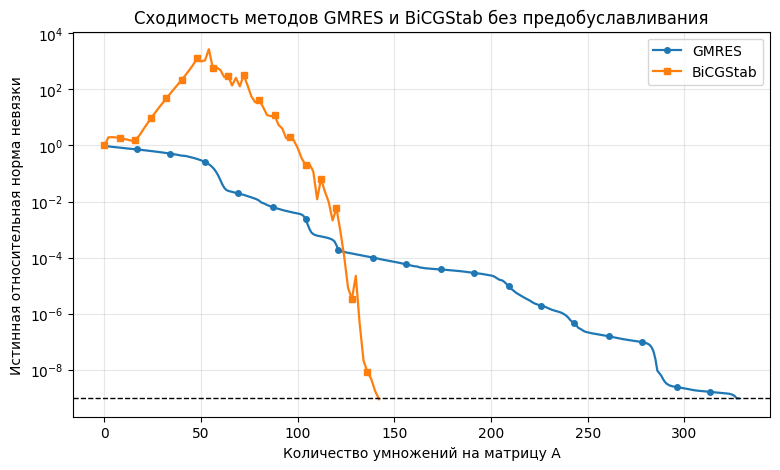

GMRES    : количество умножений A @ v =  328, норма итоговой невязки = 9.604e-10, число возрастаний невязки = 0
BiCGStab : количество умножений A @ v =  142, норма итоговой невязки = 8.933e-10, число возрастаний невязки = 32


In [ ]:
import matplotlib.pyplot as plt

# строим график: по оси абсцисс — накопленное число умножений на A,
# по оси ординат — истинная относительная невязка.

fig, ax = plt.subplots(figsize=(9, 5))

for result, marker in ((gmres_result, "o"), (bicgstab_result, "s")):
    mark_every = max(1, len(result["residual_history"]) // 18)
    ax.semilogy(
        result["matvec_history"],
        result["residual_history"],
        label=result["method"],
        marker=marker,
        markevery=mark_every,
        markersize=4,
        linewidth=1.6,
    )

# пунктирная линия показывает требуемую относительную точность
ax.axhline(1e-9, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Количество умножений на матрицу A")
ax.set_ylabel("Истинная относительная норма невязки")
ax.set_title("Сходимость методов GMRES и BiCGStab без предобуславливания")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.show()

# считаем, сколько раз норма невязки временно увеличивалась
# в случае метода BiCGStab такие увеличения допустимы и хорошо видны на графике
for result in (gmres_result, bicgstab_result):
    increases = np.count_nonzero(
        np.diff(result["residual_history"]) > 0
    )
    print(
        f"{result['method']:<9}: "
        f"количество умножений A @ v = {result['matvecs']:>4}, "
        f"норма итоговой невязки = {result['true_residual']:.3e}, "
        f"число возрастаний невязки = {increases}"
    )

Метод GMRES без перезапуска демонстрировал бы невозрастание нормы невязки в арифметике бесконечной разрядности. В приведённом примере использовался метод GMRES с перезапуском, однако на рассматриваемой задаче норма невязки тоже изменяется монотонно. В случае же метода BiCGStab заметны подъёмы и спады — это нормальное поведение метода.

По горизонтальной оси отложен не номер итерации, а суммарное число выполненных умножений на разреженную матрицу $\textbf{A}$. Это делает сравнение методов понятнее: одна полная итерация метода BiCGStab обычно содержит два таких умножения, а один внутренний шаг метода GMRES — одно. Метод, кривая которого пересекает пунктирную прямую левее, выполнил меньше умножений на матрицу $\textbf{A}$ (т.е. продемонстрировал большую эффективность). В данном случае это метод BiCGStab.

Следует иметь в виду, что проведённое сравнение не учитывает всей специфики методов. Метод GMRES накапливает векторы ортонормированного базиса (до перезапуска), а метод BiCGStab подсчитывает скалярные произведения и выполняет стабилизацию приближений. Различия сказываются на необходимом объёме памяти и времени работы; для корректного сравнения необходимо учитывать и эти параметры.


### Расчёт с ILU-предобуславливателем

Повторим расчёт, включив в него предварительное вычисление неполного LU-разложения (т.е. процедуру ILU-предобуславливания). Для этого обоим методам необходимо передать действие оператора $\textbf{P}^{-1}$

$$
\textbf{v}\quad\to\quad
\textbf{P}^{-1}\textbf{v}.
$$

Обратную матрицу $\textbf{P}^{-1}$ не вычисляют явно. Вместо этого сначала решают СЛАУ

$$
\widetilde{\textbf{L}}\textbf{z}=\textbf{v}
$$

с нижней треугольной матрицей, а затем СЛАУ

$$
\widetilde{\textbf{U}}\textbf{w}=\textbf{z}
$$

с верхней треугольной матрицей. Полученный вектор $\textbf{w}$ и есть результат применения предобуславливателя к вектору $\textbf{v}$.

При запуске методов будем отдельно учитывать время построения ILU-разложения, время выполнения итераций, количество умножений на матрицу $\textbf{A}$ и число применений предобуславливателя. Сравнение этих характеристик позволяет увидеть не только сокращение числа шагов, но и цену этого сокращения.

Для корректного сравнения будем запускать каждый из четырёх методов (GMRES и BiCGStab с предобуславливателем и без) семь раз и вычислять медианное время. Медиана менее чувствительна к случайным задержкам операционной системы, чем результат единственного запуска.

Используемое ниже сокращение "1 RHS" означает полное время решения СЛАУ с одной правой частью (1 right-hand side).

In [ ]:
# несколько раз строим ILU-разложение, чтобы оценить типичное время построения
setup_measurements = []
for _ in range(7):
    started = time.perf_counter()
    ilu = sp.sparse.linalg.spilu(A, drop_tol=1e-3, fill_factor=8)
    setup_measurements.append(time.perf_counter() - started)

setup_time = float(np.median(setup_measurements))

In [ ]:
# отношение числа ненулевых элементов матриц-сомножителей
# к числу ненулевых элементов матрицы A
actual_fill = (ilu.L.nnz + ilu.U.nnz) / A.nnz


def median_solver_result(method, A, f,
                         P_inverse=None, repeats=7):
    # возвращает характеристики метода с медианным временем запуска
    # (решение одной и той же системы повторяется для уменьшения влияния
    # случайных задержек операционной системы)
    runs = [
        solve_Krylov(method, A, f,
                     P_inverse=P_inverse, rtol=1e-9, restart=40,
        )
        for _ in range(repeats)
    ]

    # численные результаты берём из первого запуска, а время рассчитываем медианное
    result = dict(runs[0])
    result["time"] = float(
        np.median([run["time"] for run in runs])
    )
    for key in (
        "callback_steps",
        "matvecs",
        "preconditioner_calls",
    ):
        result[key] = int(
            np.median([run[key] for run in runs])
        )
    return result


# формируем четыре варианта: два метода с предобуславливанием и два метода без него
comparison_rows = []
for method in ("GMRES", "BiCGStab"):
    for label, P_inverse in (
        ("без P", None),
        ("ILU", ilu.solve),
    ):
        result = median_solver_result(
            method, A, f, P_inverse=P_inverse
        )
        comparison_rows.append(
            {
                "method": method,
                "P": label,
                "info": result["info"],
                "steps": result["callback_steps"],
                "matvecs": result["matvecs"],
                "P_calls": result["preconditioner_calls"],
                "residual": result["true_residual"],
                "solve_time": result["time"],
                "one_rhs_time": (
                    result["time"]
                    + (setup_time if P_inverse is not None else 0.0)
                ),
            }
        )

# печатаем параметры построенного предобуславливателя и итоговую сравнительную таблицу
print(f"Медианное время построения ILU: {setup_time:.4f} с")
print(f"Фактический коэффициент заполнения ILU: {actual_fill:.2f}")
print()
print(
    f"{'Метод':<10} {'P':<7} {'info':>5} {'шаги':>7} "
    f"{'A @ v':>7} {'P^(-1) @ v':>9} {'невязка':>12} "
    f"{'solve, c':>10} {'1 RHS, c':>10}"
)
for row in comparison_rows:
    print(
        f"{row['method']:<10} {row['P']:<7} "
        f"{row['info']:>5} {row['steps']:>7} "
        f"{row['matvecs']:>7} {row['P_calls']:>9} "
        f"{row['residual']:>12.3e} "
        f"{row['solve_time']:>10.4f} "
        f"{row['one_rhs_time']:>10.4f}"
    )

# варианты с наименьшим временем по двум разным критериям:
# 1) только повторное решение при уже построенном ILU
# 2) одна правая часть с учётом построения ILU
fastest_solve = min(comparison_rows, key=lambda row: row["solve_time"])
fastest_one_rhs = min(comparison_rows, key=lambda row: row["one_rhs_time"])

print()
print(
    "Минимальное время повторного решения: "
    f"{fastest_solve['method']}, {fastest_solve['P']}."
)
print(
    "Минимальное полное время для одной правой части: "
    f"{fastest_one_rhs['method']}, {fastest_one_rhs['P']}."
)

Медианное время построения ILU: 0.0088 с
Фактический коэффициент заполнения ILU: 5.25

Метод      P        info    шаги   A @ v P^(-1) @ v      невязка   solve, c   1 RHS, c
GMRES      без P       0     320     328         0    9.604e-10     0.1611     0.1611
GMRES      ILU         0      23      25        26    5.935e-10     0.0147     0.0234
BiCGStab   без P       0      71     142         0    8.933e-10     0.0095     0.0095
BiCGStab   ILU         0      11      23        23    4.913e-10     0.0093     0.0181

Минимальное время повторного решения: BiCGStab, ILU.
Минимальное полное время для одной правой части: BiCGStab, без P.


Цель предобуславливания состоит в том, чтобы уменьшить количество "дорогих" умножений на исходную матрицу $\textbf{A}$. Однако каждое применение оператора $\textbf{P}^{-1}$ тоже требует времени, а само ILU-разложение нужно предварительно построить и сохранить. Поэтому в сравнительной таблице приведены две временные характеристики:

* ```solve``` — время собственно итерационного решения;
* ```1 RHS``` — время решения одной СЛАУ вместе с построением ILU-разложения.

Для серии систем с одной матрицей и разными правыми частями ILU-разложение строят один раз, поэтому стоимость построения распределяется между всеми решениями. В такой ситуации предобуславливание обычно является выгодным.

Из таблицы видно, что в случае **одной** правой части наименьшее полное время соответствует методу BiCGStab **без** предобуславливателя. Система сравнительно небольшая, и поэтому метод BiCGStab сам по себе достигает заданной точности за умеренное число умножений на матрицу $\textbf{A}$. Добавление процедуры ILU-предобуславливания, конечно, значительно уменьшает число таких умножений, но время построения ILU-разложения оказывается больше полученной экономии ("игра не стоит свеч").

Если же ILU-разложение уже построено или требуется решить несколько систем с одной той же матрицей, более быстрым обычно оказывается метод BiCGStab **с** ILU-предобуславливателем: факторизация "оплачивается" один раз, а каждое последующее решение требует значительно меньше умножений на матрицу $\textbf{A}$.

Метод GMRES в этом тесте проигрывает в смысле времени, поскольку выполняет больше умножений на матрицу и дополнительно ортогонализует базисные векторы.

Подчеркнём, что полученные нами результаты и сделанные на их основе выводы относятся только к выбранной задаче (с конкретными параметрами). Проведённая демонстрация вовсе не означает, что один метод (BiCGStab) всегда лучше другого (GMRES). Это видно хотя бы из того, что реальное время расчёта зависит от используемого компьютера и паразитной нагрузки в виде сторонних программ, поэтому наименьшее количество операций (умножений на матрицу) не всегда отвечает наименьшему полному времени расчёта.


---

# Практические задачи

## Задача A

1.  Реализовать метод Якоби решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ в виде функции ```Jacobi_iter```. Функция должна принимать на вход три основных аргумента: матрицу СЛАУ $\textbf{A}$, вектор правой части $\textbf{f}$ и требуемую точность приближённого решения $\varepsilon$ (по умолчанию $\varepsilon=10^{-8}$). Возвращается единственный объект — одномерный массив, содержащий компоненты искомого приближённого решения СЛАУ. Предусмотреть предварительную проверку сходимости метода Якоби для заданной СЛАУ. При отсутствии сходимости возбуждать исключение ```ValueError``` с соответствующим комментарием. Желательно сделать проверку сходимости отключаемой путём добавления необязательного аргумента ```checking``` со значением ```True``` по умолчанию.

2. Выполнить сравнение реализованного метода Якоби с методом последовательных исключений Гаусса (в его пользовательской реализации), аналогичное сравнению МПИ с методом Гаусса, которое проводилось в конце предыдущего семинара. Именно, построить для обоих методов графики зависимости времени решения СЛАУ $t$ (в нс) от размерности СЛАУ $n$. Для теста использовать СЛАУ с симметричной положительно определённой матрицей, удовлетворяющей условию строгого диагонального преобладания (формула для элементов такой матрицы дана в заключительном разделе предыдущего семинара). Сделать выводы об эффективности методов.

3. Повторить пункты 1 и 2 для методов Зейделя и ПВР. Можно написать одну общую функцию ```SOR_iter``` с необязательным аргументом $\omega$, по умолчанию равным единице (поскольку при $\omega=1$ метод ПВР переходит в метод Зейделя). Выбор параметра $\omega$ для метода ПВР, отличного от метода Зейделя, остаётся на усмотрение читателя: можно выбирать его случайным из отрезка $1<\omega<2$ или сделать интерактивный график с ползунком для $\omega$.

4. Сравнить все три итерационных метода (Якоби, Зейделя и ПВР) между собой, построив аналогичный график с тремя кривыми.

5. Воспользовавшись примерами из задачи 2 (или примерами, подобранными самостоятельно), продемонстрировать на практике, что сходимость метода Якоби и сходимость метода Зейделя никак не связаны друг с другом (если размерность решаемой СЛАУ $n>2$).

При написании программ рекомендуется руководствоваться теми принципами реализации итерационных процессов, которые были разобраны на предыдущем семинаре.

## Задача B

Написать программу для решения СЛАУ

$$
  \begin{pmatrix}
    1 & 0 & 1/2 & 1/3 \\
    0 & 1 & 1/3 & 1/4 \\
    1/2 & 1/3 & 1 & 0 \\
    1/3 & 1/4 & 0 & 1
  \end{pmatrix}
  \begin{pmatrix}
    x_1 \\
    x_2 \\
    x_3 \\
    x_4
  \end{pmatrix}=
  \begin{pmatrix}
    67/60 \\
    31/30 \\
    23/20 \\
    67/60
  \end{pmatrix}
$$

методом последовательной верхней релаксации с параметром $\omega$. Построить график зависимости количества итераций $s$, необходимого для достижения заданной точности $\varepsilon$, от $\omega$. Определить по графику оптимальное значение параметра $\omega_\text{opt}$. Есть ли смысл решать данную СЛАУ итерационным методом?

## Задача C


Для модельной разреженной СЛАУ из демонстрации сравнить методы GMRES и BiCGStab без предобуславливания и с ILU.

1. Изменяя `drop_tol` и `fill_factor`, записать число итераций, время построения ILU-разложения, время решения, истинную относительную невязку и коэффициент заполнения.

2. Для каждой пары параметров сравнить полное время решения одной СЛАУ и серии из десяти СЛАУ с различными правыми частями.

3. Построить графики зависимости числа итераций и полного времени от коэффициента заполнения.

4. Объяснить, почему вариант с наименьшим числом итераций не обязан иметь наименьшее полное время.

# Литература и другие источники

**Видеозаписи:**

1. Вычислительная математика — лекция 4. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/1MzfHvgqb78?si=bpiHgBxvgt-9TJEO&t=605) (YouTube).

2. Вычислительная математика — лекция 5. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/9yDoZU_WkuQ?si=FucSoS4marfSNVIz&t=73) (YouTube).

4. Вычислительная математика — лекция 5. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=vS_3zWYYFVg) (YouTube).

5. Методы Якоби и Зейделя решения СЛАУ — видеоразбор темы. Преподаватель — Н.И. Караваева. [Ссылка](https://vkvideo.ru/video-212608323_456239025) (VK Видео).

**Рекомендуемая литература (с комментариями):**

Изложение теории итерационных методов решения СЛАУ можно найти как в классических курсах по вычислительной математике, так и в монографиях по прикладной линейной алгебре. Приступая к чтению литературы, следует иметь в виду, что **в разных книгах одни и те же названия могут относиться к похожим, но, вообще говоря, различным итерационным методам** (чаще всего в разных смыслах употребляются названия "метод простых итераций" и "метод Зейделя"). Мы рекомендуем следующие учебники и монографии:

1.   *А.А. Самарский, А.В. Гулин. Численные методы.* Итерационным методам решения СЛАУ посвящена вторая глава книги (стр. 82—126). Примечательно, что в неё включено изложение некоторых сведений о многочленах Чебышёва (см. пятый параграф); правда, сделано это по причинам, совсем не связанным с МНК. Шестой параграф (как, впрочем, и пятый) при первом чтении можно пропустить (в нём разбираются оставшиеся за рамками семинара итерационные методы с чебышёвским набором параметров). Заслуживает внимания теорема 1 второго параграфа (стр. 86), дающая достаточное условие сходимости итерационных процессов, представленных в канонической форме; в других источниках эту теорему часто называют теоремой Самарского. В книге использована та же терминология, что и в тексте семинара (те же названия методов). Среди прочих источников в списке эта книга является, пожалуй, наилучшей в том смысле, что она наиболее удачно сочетает глубину и педагогичность изложения.  

2.  *Дж. Голуб, Ч. Ван Лоун. Матричные вычисления.* К теме семинара относится десятая глава монографии (стр. 452—481), в которой удачно изложена идея расщепления (в изложении авторов она положена в основу построения итерационных процессов). Поскольку книга, как мы уже отмечали, носит прикладной характер, приведённые в ней теоретические сведения по классическим методам (Якоби, Зейделя, ПВР) довольно скудны (но для наших целей вполне достаточны). С другой стороны, много места отведено важному методу сопряжённых градиентов (стр. 461—481), который не разбирался в тексте семинара. В конце каждого раздела можно найти обстоятельные списки литературы (правда, в основном журнальной англоязычной).

3.  *А.И. Лобанов, И.Б. Петров. Вычислительная математика: курс лекций.* Теоретические сведения по классическим итерационным методам (МПИ, методы Якоби, Зейделя и ПВР) изложены в пункте 2.5 второй лекции (стр. 54—61). Методам вариационного типа посвящён пункт 2.6 (стр. 61—67). Изложение носит конспективный характер и почти не выходит за рамки семинара в смысле объёма охватываемого материала. Исключение составляет пункт 2.6, в котором более подробно изложены методы наискорейшего спуска и минимальных невязок, а также разобран метод сопряжённых градиентов. Напомним, что помимо указанного учебника существует книга тех же авторов с похожим названием: "Лекции по вычислительной математике" (издание 2006 г.). Лучше пользоваться названной выше книгой (издания 2021 г.). В более новом учебнике устранены замеченные опечатки, а материал отдельных лекций значительно переработан.

4. *В.И. Косарев. 12 лекций по вычислительной математике.* На прошлом семинаре мы уже рекомендовали третью лекцию (стр. 38—50) из этого курса в связи с изучением МПИ. В той же лекции очень лаконично изложены методы Якоби и Зейделя. К сожалению, совершенно не упоминается метод ПВР. В силу малой подробности изложения этот источник можно рекомендовать лишь как быстрое введение в тему. Зато текст читается очень легко. В конце лекции (после дополнений) приведён список литературы, по которой итерационные методы можно изучить более подробно.

5. *Л. Хейгеман, Д. Янг. Прикладные итерационные методы.* Эта книга **целиком** посвящена итерационным методам решения СЛАУ, что выгодно отличает её от других учебников и монографий, в которых той же теме отведено лишь несколько глав. На протяжении всей книги рассматриваются пять основных методов, в том числе МПИ (он фигурирует под названием "метод Ричардсона"), методы Якоби, Зейделя и ПВР. Основные сведения об этих методах собраны во второй главе (стр. 31—54), и для нужд общего курса вычислительной математики достаточно её выборочного прочтения (при необходимости можно периодически обращаться к первой главе, носящей справочный характер). Любопытна сравнительная таблица скоростей сходимости рассматриваемых методов (стр. 48), построенная для случая СЛАУ, получившейся после аппроксимации некоторой специально выбранной задачи (двумерное уравнение Пуассона). Прочие главы монографии содержат материал, выходящий за рамки нашего курса, но весьма интересный как с теоретической, так и с практической точек зрения.

6.  *М.Ю. Баландин, Э.П. Шурина. Методы решения СЛАУ большой размерности.* Учебное пособие Новосибирского государственного технического университета. В третьей главе (стр. 21—26) с опорой на идею расщепления коротко изложены основные итерационные методы, упомянутые в тексте семинара (правда, почему-то не приведены конкретные условия их сходимости — сформулирован лишь общий критерий). Заслуживают внимания последующие главы (стр. 27—56), в которых излагаются методы проекционного типа, **в том числе методы GMRES и BiCGStab**; приведены элементарные сведения о подпространствах Крылова. Имеется материал по предобуславливанию. Для всех рассматриваемых методов приведены псевдокоды. [Ссылка](https://masters.donntu.ru/2006/fvti/horoshilov/library/files/MethodsSLE.pdf?ysclid=mt8xxo6v37653023117) на пособие.

7.  *Д.К. Фаддеев, В.Н. Фаддеева. Вычислительные методы линейной алгебры.* Мы уже неоднократно рекомендовали эту фундаментальную монографию как источник, содержащий очень подробные сведения по многим вопросам прикладной линейной алгебры. Книга содержит обширный материал и по итерационным методам решения СЛАУ: классические методы и методы релаксации изложены в главе III (стр. 204—256), а градиентные методы — в параграфах 70—73 главы VII (стр. 456—479). Можно также найти сведения по так называемым **методам сопряжённых направлений** (глава VI, параграфы 68—69, стр. 433—454), в том числе по методу сопряжённых градиентов (стр. 441—446). Однако пользоваться сведениями из перечисленных глав следует с большой осмотрительностью, поскольку названия методов во многих случаях отличаются от общепринятых и современных (например, в главе III упоминается метод Зейделя, но под ним понимается не изученный на семинаре метод Зейделя, а "одношаговый циклический процесс"; тот метод, который мы называли методом Зейделя, назван методом Некрасова). Впрочем, это неудобство искупается глубиной проработки материала.

8.  *В.И. Крылов, В.В. Бобков, П.И. Монастырный. Начала теории вычислительных методов. Линейная алгебра и нелинейные уравнения.* Это четвёртая книга авторов из серии "Начала вычислительных методов". Теме семинара посвящён второй параграф первой главы (стр. 23—58). При чтении текста чувствуется сильное влияние монографии Фаддеевых: логика изложения во многом похожа. Однако путаница с названиями методов практически устранена (в частности, термин "метод Зейделя" используется в том же смысле, что и в тексте семинара; несколько иначе трактуется термин "метод простой итерации" — в книге так называется целый класс методов). В пятом параграфе той же главы (стр. 86—111) изложены некоторые итерационные методы, основанные на **идее ортогонализации**, в том числе и метод сопряжённых градиентов (стр. 96). Вообще говоря, книга представляет собой интересную попытку совместного рассмотрения вопросов прикладной линейной алгебры и алгоритмов решения нелинейных уравнений с общим введением, посвящённым операторным уравнениям.

Специальная литература по методам GMRES, BiCGStab и предобуславливанию:

9. *Y. Saad. Iterative Methods for Sparse Linear Systems.* Главы 6–10 (стр. 157–368): методы Крылова, GMRES, BiCGStab и предобуславливание. Много полезного материала, изложенного очень доступно. В сети легко найти издание 2003 г. [Ссылка.](https://www-users.cse.umn.edu/~saad/IterMethBook_2ndEd.pdf)

10. *A. Greenbaum. Iterative Methods for Solving Linear Systems.* Главы 2, 5, 10 и 11: GMRES, методы семейства BiCG, сравнение предобуславливателей и неполные разложения. Эта книга менее доступна, чем предыдущая. [Страница книги.](https://epubs.siam.org/doi/10.1137/1.9781611970937)

11. *Y. Saad, M.H. Schultz. GMRES: A Generalized Minimal Residual Algorithm for Solving Nonsymmetric Linear Systems.* SIAM Journal on Scientific and Statistical Computing, 7 (1986), 856–869. [Статья.](https://epubs.siam.org/doi/10.1137/0907058)

12. *H.A. van der Vorst. Bi-CGSTAB: A Fast and Smoothly Converging Variant of Bi-CG for the Solution of Nonsymmetric Linear Systems.* SIAM Journal on Scientific and Statistical Computing, 13 (1992), 631–644. [Статья.](https://epubs.siam.org/doi/10.1137/0913035)

13. *R. Barrett et al. Templates for the Solution of Linear Systems: Building Blocks for Iterative Methods.* SIAM, 1994. Практические алгоритмы и критерии выбора методов. [Полный текст в Netlib.](https://www.netlib.org/templates/templates.pdf)

# Контрольные вопросы

1.   Какие итерационные методы называются двухслойными? Запишите их в общем виде (через оператор перехода $\textbf{R}$).
2.   Сформулируйте общий критерий сходимости итерационных методов решения СЛАУ.
3.   Что такое расщепление матрицы СЛАУ? матрица расщепления? Запишите итерационный метод решения СЛАУ в общем виде (через матрицу расщепления $\textbf{M}$).
4.   По какому принципу выбирается матрица расщепления при построении основных итерационных методов решения СЛАУ?
5.   Запишите метод Якоби в векторно-матричном виде.
6.   Запишите расчётную (покомпонентную) формулу метода Якоби.
7.   Запишите метод Зейделя в векторно-матричном виде.
8.   Запишите расчётную (покомпонентную) формулу метода Зейделя.
9.  Чем принципиально отличаются методы Якоби и Зейделя?
10.  Запишите каноническую форму двухслойных итерационных процессов. Какие изученные Вами итерационные методы охватываются этой формулой?
11.   Какие методы решения СЛАУ называются явными? неявными?
12.  Какие итерационные процессы называются стационарными? нестационарными?
13.  Всегда ли для решения линейной задачи применяются линейные численные методы?
14.  Запишите операторы перехода для методов Якоби и Зейделя.
15.  Сформулируйте критерии сходимости методов Якоби и Зейделя.
16.  Сформулируйте достаточное условие сходимости метода Якоби.
17.  Сформулируйте два достаточных условия сходимости метода Зейделя.
18.  Всегда ли метод Зейделя сходится быстрее метода Якоби? Если не всегда, то при каком условии он сходится быстрее?
19.  Как связаны между собой сходимость метода Якоби и сходимость метода Зейделя?
20.  Запишите метод ПВР в векторно-матричном виде.
21.  Запишите расчётную (покомпонентную) формулу метода ПВР.
22.  Сформулируйте достаточное условие сходимости метода ПВР (теорему Островского—Райха).
23.  Напишите формулу для оптимального параметра релаксации в методе ПВР. При каких условиях она применима?
24.  Почему метод ПВР так называется? В чём заключается принцип релаксации построения итерационных методов? Почему релаксация называется последовательной (покоординатной)?
25.  Как строятся градиентные итерационные методы? Приведите примеры таких методов.
26.  Из каких векторов строится пространство допустимых поправок в методе GMRES?
27.  Как процесс Арнольди строит очередной ортонормированный базисный вектор? Какие операции выполняются на одном шаге?
28.  Запишите расчётную формулу процесса ортогонализации Арнольди в матричном виде. Каковы размеры матриц, входящих в эту формулу?
29.  Какая матрица называется верхней матрицей Хессенберга? Почему матрица такой структуры возникает в процессе Арнольди?
30.  Какую задачу минимизации решает метод GMRES и почему возникающую задачу МНК называют малой?
31.  Зачем перезапускают метод GMRES? Что означает термин "стагнация"?
32.  В чём заключается стабилизирующий шаг метода BiCGStab? Почему он не гарантирует монотонного убывания невязки?
33.  Чем метод BiCGStab отличается от метода GMRES? Почему нельзя сравнивать только количество итераций, необходимых для этих методов?
34.  В чём заключается явление срыва итераций метода BiCGStab? Какую проверку желательно выполнять после остановки итерационного процесса?
35.  В чём заключается предобуславливание СЛАУ? Почему матрицу предобуславливателя не обращают явно?
36.  В чём состоит идея неполного LU-разложения? Чем отличаются алгоритмы предобуславливания ILU(0), ILU($k$) и ILUT?
37.  Как связаны точность ILU-разложения, заполнение матриц-сомножителей и стоимость одной итерации?
38.  Какие величины необходимо сравнивать при оценке эффективности предобуславливателя в итерационных методах, применяемых для решения СЛАУ с одной и многими правыми частями?
